# DPO adapter evaluation on unseen WVS survey questions

This notebook evaluates the base Llama model and the country-specific DPO+QLoRA adapters against empirical population response distributions.

It produces the following comparisons:

- base model on USA data
- base model on MEX data
- USA adapter on USA data
- USA adapter on MEX data
- MEX adapter on USA data
- MEX adapter on MEX data

For every question, the model is scored on every valid response code. The option log-probabilities are normalized into a response distribution and compared with the weighted population distribution using total variation distance, Jensen-Shannon divergence, Brier score, cross-entropy, and—where the response scale is ordered—Wasserstein distance and moment errors.

By default the country is **not named in the prompt**, matching the earlier adapter-evaluation setup. Thus the country-specific behavior must come from the adapter rather than explicit country conditioning. Set `PROMPT_COUNTRY_CONDITIONING = True` to run the alternative country-conditioned test.

In [ ]:
!pip -q install -U "transformers>=4.41.0" "accelerate>=0.30.0" \
                 "peft>=0.11.1" "bitsandbytes>=0.46.1" "safetensors>=0.4.3" \
                 "pyarrow>=15.0.0" "scipy>=1.10.0" "matplotlib>=3.7.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 56.9 MB/s eta 0:00:00


In [ ]:
# If running in Google Colab.
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import gc
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

## Configuration

In [ ]:
# ----------------------------
# Model and path configuration
# ----------------------------

BASE_MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

DATA_DIR = Path("/content/drive/MyDrive/DPO/eval_new_data")
DATA_DIR_ADAPTER=Path("/content/drive/MyDrive/DPO/")
RESULTS_DIR = DATA_DIR / "eval_results_wvs_wave7"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

QUESTION_MAP_FILE = DATA_DIR / "question_map_wvs_edited.csv"

DATA_COUNTRY_CODES = ["USA", "MEX"]
ADAPTER_COUNTRY_CODES = ["USA", "MEX"]

COUNTRY_NAMES = {
    "USA": "the United States",
    "MEX": "Mexico",
}

# Adapter-directory naming is kept consistent with the earlier notebooks:
# USA data uses the USA code, while the adapter path uses US.
PATH_COUNTRY_CODES = {
    "USA": "US",
    "MEX": "MEX",
}

SURVEY_FILES = {
    "USA": DATA_DIR / "USA_WVS_wave7.parquet",
    "MEX": DATA_DIR / "MEX_WVS_wave7.parquet",
}

DATA_DIR_ADAPTER = Path("/content/drive/MyDrive/DPO/dpo_qlora_adapters")

ADAPTER_DIRS = {
    country: DATA_DIR_ADAPTER / PATH_COUNTRY_CODES.get(country, country)
    for country in ADAPTER_COUNTRY_CODES
}

# Both attached parquet files contain a column named "weight".
# Set a value to None to use unweighted response frequencies for that country.
USE_SURVEY_WEIGHTS = True
WEIGHT_COLUMNS = {
    "USA": "weight",
    "MEX": "weight",
}

# The previous training/evaluation prompt did not explicitly mention a country.
# Keep False for the primary test of what the adapter itself has learned.
PROMPT_COUNTRY_CONDITIONING = False

# Numerical scoring settings.
MAX_PROMPT_TOKENS = 768
MAX_COMPLETION_TOKENS = 16
OPTION_SCORE_TEMPERATURE = 1.0
LENGTH_NORMALIZE_OPTION_LOGPROBS = False
COMPLETION_PREFIX = " "

# Generate one deterministic answer per model/question in addition to scoring
# all valid response options.
SAVE_GENERATED_ANSWERS = True
GENERATION_MAX_NEW_TOKENS = 32
GENERATION_DO_SAMPLE = False

# Set to a small integer for a smoke test; None evaluates all questions.
MAX_QUESTIONS = None

# The numeric-open questions are evaluated over the union of observed valid
# integer responses in the two population files.
INCLUDE_NUMERIC_OPEN = True
NUMERIC_VALID_RANGES = {
    "Q261": (1900, 2010),  # year of birth
    "Q262": (15, 110),    # age in years
}
MAX_NUMERIC_SUPPORT = 150

# These response codes are categories rather than ordered positions.
# All other mapped questions are treated as ordered for moment/Wasserstein analytics.
NOMINAL_QUESTION_IDS = {"Q174", "Q260"}

BOOTSTRAP_REPS = 2000
RANDOM_SEED = 42
EPS = 1e-12

print("Question map:", QUESTION_MAP_FILE)
print("Survey files:", SURVEY_FILES)
print("Adapter dirs:", ADAPTER_DIRS)
print("Results dir:", RESULTS_DIR)

Question map: /content/drive/MyDrive/DPO/eval_new_data/question_map_wvs_edited.csv
Survey files: {'USA': PosixPath('/content/drive/MyDrive/DPO/eval_new_data/USA_WVS_wave7.parquet'), 'MEX': PosixPath('/content/drive/MyDrive/DPO/eval_new_data/MEX_WVS_wave7.parquet')}
Adapter dirs: {'USA': PosixPath('/content/drive/MyDrive/DPO/dpo_qlora_adapter_llama3_3594_US_3'), 'MEX': PosixPath('/content/drive/MyDrive/DPO/dpo_qlora_adapter_llama3_3594_MEX_3')}
Results dir: /content/drive/MyDrive/DPO/eval_new_data/eval_results_wvs_wave7


In [ ]:
# Hugging Face login; an access token may be requested.
from huggingface_hub import notebook_login
notebook_login()

## Load and validate the question map and population data

In [ ]:
def canonical_code(value):
    """Return a stable string representation for numeric response codes."""
    number = float(value)
    if not np.isfinite(number):
        raise ValueError(f"Non-finite response code: {value}")
    if number.is_integer():
        return str(int(number))
    return format(number, "g")


def parse_semicolon_field(value):
    if pd.isna(value):
        return []
    return [part.strip() for part in str(value).split(";") if part.strip()]


def parse_fixed_options(row):
    raw_codes = parse_semicolon_field(row["ResponseCodes"])
    codes = [canonical_code(code) for code in raw_codes]

    labels = parse_semicolon_field(row["ResponseLabels"])
    # The supplied map has a few missing/extra labels. Preserve code order,
    # truncate extra labels, and use the code itself for any missing label.
    labels = labels[:len(codes)]
    labels += codes[len(labels):]
    labels = [label if str(label).lower() != "nan" else code for code, label in zip(codes, labels)]

    return codes, labels


def load_inputs():
    question_map = pd.read_csv(QUESTION_MAP_FILE)
    question_map = question_map.drop(columns=["Unnamed: 0"], errors="ignore").copy()
    question_map["Question"] = question_map["Question"].astype(str).str.strip()
    question_map["StandaloneQuestion"] = question_map["StandaloneQuestion"].astype(str).str.strip()

    if question_map["Question"].duplicated().any():
        duplicates = question_map.loc[question_map["Question"].duplicated(), "Question"].tolist()
        raise ValueError(f"Duplicate question IDs in map: {duplicates}")

    survey_frames = {}
    for country, path in SURVEY_FILES.items():
        frame = pd.read_parquet(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        survey_frames[country] = frame

        missing_questions = sorted(set(question_map["Question"]) - set(frame.columns))
        if missing_questions:
            raise ValueError(f"{country} parquet is missing mapped columns: {missing_questions}")

        weight_column = WEIGHT_COLUMNS.get(country)
        if USE_SURVEY_WEIGHTS and weight_column and weight_column not in frame.columns:
            raise ValueError(f"Weight column {weight_column!r} not found for {country}")

        print(f"{country}: {len(frame):,} respondents, {len(frame.columns):,} columns")

    return question_map, survey_frames


question_map, survey_frames = load_inputs()
display(question_map[["Question", "ResponseType", "ResponseCodes", "ResponseLabels", "StandaloneQuestion"]])

USA: 2,596 respondents, 44 columns
MEX: 1,741 respondents, 44 columns


,Question,ResponseType,ResponseCodes,ResponseLabels,StandaloneQuestion
0,Q12,multiple_response_max_5,1; 2,Yes; No,Is tolerance and respect for other people one ...
1,Q13,multiple_response_max_5,1; 2,Yes; No,"Is thrift, saving money and things one of the ..."
2,Q14,multiple_response_max_5,1; 2,Yes; No,"Is determination, perseverance one of the qual..."
3,Q43,single_choice_3,1; 2; 3,Good thing; Don't mind; Bad thing,"If this change were to happen, would it be a g..."
4,Q50,scale_1_10,1; 2; 3; 4; 5; 6; 7; 8; 9; 10,Completely dissatisfied; 2; 3; 4; 5; 6; 7; 8; ...,How satisfied are you with the financial situa...
5,Q57,single_choice_2,1; 2,Most people can be trusted; Need to be very ca...,"Generally speaking, would you say that most pe..."
6,Q58,single_choice_4,1; 2; 3; 4,Trust completely; Trust somewhat; Do not trust...,"How much do you trust your family: completely,..."
7,Q59,single_choice_4,1; 2; 3; 4,Trust completely; Trust somewhat; Do not trust...,How much do you trust your neighborhood: compl...
8,Q60,single_choice_4,1; 2; 3; 4,Trust completely; Trust somewhat; Do not trust...,How much do you trust people you know personal...
9,Q61,single_choice_4,1; 2; 3; 4,Trust completely; Trust somewhat; Do not trust...,How much do you trust people you meet for the ...


In [ ]:
def observed_numeric_support(question_id, survey_frames):
    values = []
    lower, upper = NUMERIC_VALID_RANGES.get(question_id, (-np.inf, np.inf))

    for frame in survey_frames.values():
        series = pd.to_numeric(frame[question_id], errors="coerce")
        series = series[np.isfinite(series)]
        series = series[(series >= lower) & (series <= upper)]
        values.extend(series.tolist())

    if not values:
        raise ValueError(f"No valid numeric responses found for {question_id}")

    # These two WVS questions are integer-valued.
    support = sorted({int(round(value)) for value in values})
    if len(support) > MAX_NUMERIC_SUPPORT:
        raise ValueError(
            f"{question_id} has {len(support)} observed values, above "
            f"MAX_NUMERIC_SUPPORT={MAX_NUMERIC_SUPPORT}. Adjust the range or limit."
        )
    return [str(value) for value in support]


def build_question_specs(question_map, survey_frames):
    specs = []

    for _, row in question_map.iterrows():
        question_id = row["Question"]
        response_type = str(row["ResponseType"])
        is_numeric_open = response_type == "numeric_open"

        if is_numeric_open:
            if not INCLUDE_NUMERIC_OPEN:
                continue
            codes = observed_numeric_support(question_id, survey_frames)
            labels = codes.copy()
        else:
            codes, labels = parse_fixed_options(row)

        if len(codes) < 2:
            raise ValueError(f"Question {question_id} has fewer than two valid response codes")

        specs.append({
            "question_id": question_id,
            "question_text": row["StandaloneQuestion"],
            "response_type": response_type,
            "codes": codes,
            "labels": labels,
            "is_numeric_open": is_numeric_open,
            "is_ordered": question_id not in NOMINAL_QUESTION_IDS,
            "gps_dimension": row.get("gps_dimension"),
        })

    if MAX_QUESTIONS is not None:
        specs = specs[:MAX_QUESTIONS]

    return specs


question_specs = build_question_specs(question_map, survey_frames)
question_specs_df = pd.DataFrame([{**spec, "n_options": len(spec["codes"])} for spec in question_specs])

print(f"Questions to evaluate: {len(question_specs)}")
print(f"Total candidate responses per model/prompt condition: {question_specs_df['n_options'].sum()}")
display(question_specs_df[["question_id", "response_type", "n_options", "is_ordered", "codes", "labels"]])

Questions to evaluate: 35
Total candidate responses per model/prompt condition: 328


,question_id,response_type,n_options,is_ordered,codes,labels
0,Q12,multiple_response_max_5,2,True,"[1, 2]","[Yes, No]"
1,Q13,multiple_response_max_5,2,True,"[1, 2]","[Yes, No]"
2,Q14,multiple_response_max_5,2,True,"[1, 2]","[Yes, No]"
3,Q43,single_choice_3,3,True,"[1, 2, 3]","[Good thing, Don't mind, Bad thing]"
4,Q50,scale_1_10,10,True,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[Completely dissatisfied, 2, 3, 4, 5, 6, 7, 8,..."
5,Q57,single_choice_2,2,True,"[1, 2]","[Most people can be trusted, Need to be very c..."
6,Q58,single_choice_4,4,True,"[1, 2, 3, 4]","[Trust completely, Trust somewhat, Do not trus..."
7,Q59,single_choice_4,4,True,"[1, 2, 3, 4]","[Trust completely, Trust somewhat, Do not trus..."
8,Q60,single_choice_4,4,True,"[1, 2, 3, 4]","[Trust completely, Trust somewhat, Do not trus..."
9,Q61,single_choice_4,4,True,"[1, 2, 3, 4]","[Trust completely, Trust somewhat, Do not trus..."


## Construct empirical population response distributions

In [ ]:
def get_country_weights(frame, country):
    if not USE_SURVEY_WEIGHTS or WEIGHT_COLUMNS.get(country) is None:
        return pd.Series(np.ones(len(frame), dtype=float), index=frame.index), None

    weight_column = WEIGHT_COLUMNS[country]
    weights = pd.to_numeric(frame[weight_column], errors="coerce")
    weights = weights.where(np.isfinite(weights) & (weights > 0))
    return weights, weight_column


def build_population_distributions(question_specs, survey_frames):
    rows = []

    for country, frame in survey_frames.items():
        weights, weight_column = get_country_weights(frame, country)

        for spec in question_specs:
            question_id = spec["question_id"]
            answers = pd.to_numeric(frame[question_id], errors="coerce")
            code_values = np.array([float(code) for code in spec["codes"]], dtype=float)

            valid_answer = answers.isin(code_values)
            valid_weight = weights.notna()
            valid = valid_answer & valid_weight

            n_valid = int(valid.sum())
            total_weight = float(weights.loc[valid].sum())
            if n_valid == 0 or total_weight <= 0:
                raise ValueError(f"No valid responses for {country} / {question_id}")

            for option_index, (code, label) in enumerate(zip(spec["codes"], spec["labels"])):
                code_value = float(code)
                selected = valid & answers.eq(code_value)
                weighted_count = float(weights.loc[selected].sum())
                unweighted_count = int(selected.sum())

                rows.append({
                    "eval_country": country,
                    "question_id": question_id,
                    "question_text": spec["question_text"],
                    "response_type": spec["response_type"],
                    "gps_dimension": spec["gps_dimension"],
                    "is_ordered": spec["is_ordered"],
                    "is_numeric_open": spec["is_numeric_open"],
                    "option_index": option_index,
                    "option_code": code,
                    "option_value": code_value,
                    "option_label": label,
                    "unweighted_count": unweighted_count,
                    "weighted_count": weighted_count,
                    "population_prob": weighted_count / total_weight,
                    "n_valid": n_valid,
                    "total_weight": total_weight,
                    "weight_column": weight_column,
                })

    population = pd.DataFrame(rows)

    probability_checks = (
        population.groupby(["eval_country", "question_id"])["population_prob"]
        .sum()
        .sub(1.0)
        .abs()
    )
    if probability_checks.max() > 1e-8:
        raise AssertionError("Population probabilities do not sum to one")

    return population


population_long = build_population_distributions(question_specs, survey_frames)
population_long.to_csv(RESULTS_DIR / "population_response_distributions.csv", index=False)

population_summary = (
    population_long.groupby(["eval_country", "question_id"], as_index=False)
    .agg(n_valid=("n_valid", "first"), total_weight=("total_weight", "first"))
)
display(population_summary.head(10))

,eval_country,question_id,n_valid,total_weight
0,MEX,Q101,1738,1738.086933
1,MEX,Q103,1740,1740.218130
2,MEX,Q106,1728,1727.486522
3,MEX,Q107,1670,1673.103489
4,MEX,Q109,1729,1729.522813
5,MEX,Q12,1741,1741.144071
6,MEX,Q13,1739,1739.460280
7,MEX,Q14,1739,1739.460280
8,MEX,Q174,1730,1729.494621
9,MEX,Q176,1724,1723.237251


## Prompt formatting and option log-probabilities

In [ ]:
def build_survey_user_prompt(spec, prompt_country=None):
    if prompt_country is None:
        persona = "Answer this questionnaire as an individual person."
    else:
        persona = f"Answer this questionnaire as a typical adult living in {COUNTRY_NAMES[prompt_country]}."

    if spec["is_numeric_open"]:
        response_instruction = (
            "Give one whole-number response. Return only the number, with no words or explanation."
        )
    else:
        option_lines = "\n".join(
            f"{code}: {label}"
            for code, label in zip(spec["codes"], spec["labels"])
        )
        response_instruction = (
            "Select exactly one response code from the options below.\n"
            f"{option_lines}\n\n"
            "Return only the response code, with no words or explanation."
        )

    return (
        f"{persona} Respond naturally and sincerely, as someone would in real life. "
        "Do not mention being an AI or assistant.\n\n"
        f"Question:\n{spec['question_text']}\n\n"
        f"{response_instruction}\n\n"
        "Answer:"
    )


def format_prompt_text(tokenizer, prompt_text):
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt_text}],
        tokenize=False,
        add_generation_prompt=True,
    )


def prepare_prompt_for_model(
    tokenizer,
    prompt_text,
    max_prompt_tokens=MAX_PROMPT_TOKENS,
):
    """Return the full chat prompt and the exact prompt-token sequence used."""
    formatted_prompt = format_prompt_text(tokenizer, prompt_text)
    full_prompt_ids = tokenizer(
        formatted_prompt,
        add_special_tokens=False,
    ).input_ids

    prompt_was_truncated = len(full_prompt_ids) > max_prompt_tokens
    model_prompt_ids = (
        full_prompt_ids[-max_prompt_tokens:]
        if prompt_was_truncated
        else full_prompt_ids
    )

    model_prompt_text = tokenizer.decode(
        model_prompt_ids,
        skip_special_tokens=False,
        clean_up_tokenization_spaces=False,
    )

    return {
        "formatted_prompt": formatted_prompt,
        "model_prompt_ids": model_prompt_ids,
        "model_prompt_text": model_prompt_text,
        "prompt_token_count_before_truncation": len(full_prompt_ids),
        "prompt_token_count_model": len(model_prompt_ids),
        "prompt_was_truncated": prompt_was_truncated,
    }


def get_model_device(model):
    return next(model.parameters()).device


@torch.no_grad()
def sequence_logprob(
    model,
    tokenizer,
    prompt_text,
    completion_text,
    max_prompt_tokens=MAX_PROMPT_TOKENS,
    max_completion_tokens=MAX_COMPLETION_TOKENS,
):
    """Sum log p(completion | prompt) over completion tokens only."""
    model.eval()
    device = get_model_device(model)

    prepared_prompt = prepare_prompt_for_model(
        tokenizer=tokenizer,
        prompt_text=prompt_text,
        max_prompt_tokens=max_prompt_tokens,
    )
    prompt_ids = prepared_prompt["model_prompt_ids"]
    completion_ids = tokenizer(
        completion_text,
        add_special_tokens=False,
    ).input_ids

    if len(completion_ids) > max_completion_tokens:
        completion_ids = completion_ids[:max_completion_tokens]
    if not completion_ids:
        raise ValueError("Completion tokenized to an empty sequence")

    input_ids = prompt_ids + completion_ids
    labels = [-100] * len(prompt_ids) + completion_ids

    input_ids = torch.tensor([input_ids], device=device)
    labels = torch.tensor([labels], device=device)

    logits = model(input_ids=input_ids).logits
    shifted_logits = logits[:, :-1, :]
    shifted_labels = labels[:, 1:]
    log_probs = torch.log_softmax(shifted_logits, dim=-1)

    mask = shifted_labels.ne(-100)
    safe_labels = shifted_labels.masked_fill(~mask, 0)
    token_log_probs = log_probs.gather(
        -1,
        safe_labels.unsqueeze(-1),
    ).squeeze(-1)
    completion_logprob = (token_log_probs * mask).sum()

    return float(completion_logprob.detach().cpu()), int(mask.sum().item())


@torch.no_grad()
def generate_model_answer(
    model,
    tokenizer,
    prompt_text,
    max_prompt_tokens=MAX_PROMPT_TOKENS,
    max_new_tokens=GENERATION_MAX_NEW_TOKENS,
):
    """Generate one answer with the same prompt construction used for scoring."""
    model.eval()
    device = get_model_device(model)

    prepared_prompt = prepare_prompt_for_model(
        tokenizer=tokenizer,
        prompt_text=prompt_text,
        max_prompt_tokens=max_prompt_tokens,
    )
    prompt_ids = prepared_prompt["model_prompt_ids"]

    input_ids = torch.tensor([prompt_ids], device=device)
    attention_mask = torch.ones_like(input_ids)

    generated = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        do_sample=GENERATION_DO_SAMPLE,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
        use_cache=True,
    )

    generated_ids = generated[0, input_ids.shape[1]:]
    generated_answer_raw = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )

    return {
        "generated_answer_raw": generated_answer_raw,
        "generated_answer": generated_answer_raw.strip(),
        "generated_token_count": int(generated_ids.numel()),
    }


def stable_softmax(values, temperature=1.0):
    values = np.asarray(values, dtype=float) / float(temperature)
    values = values - np.max(values)
    exp_values = np.exp(values)
    return exp_values / exp_values.sum()


def score_model_questions(model, tokenizer, model_name, question_specs, prompt_country=None):
    rows = []
    country_label = prompt_country if prompt_country is not None else "unconditioned"

    for spec in tqdm(question_specs, desc=f"Scoring {model_name} ({country_label})"):
        prompt_text = build_survey_user_prompt(
            spec,
            prompt_country=prompt_country,
        )
        prepared_prompt = prepare_prompt_for_model(
            tokenizer=tokenizer,
            prompt_text=prompt_text,
        )

        if SAVE_GENERATED_ANSWERS:
            generation = generate_model_answer(
                model=model,
                tokenizer=tokenizer,
                prompt_text=prompt_text,
            )
            generated_answer_raw = generation["generated_answer_raw"]
            generated_answer = generation["generated_answer"]
            generated_token_count = generation["generated_token_count"]
        else:
            generated_answer_raw = None
            generated_answer = None
            generated_token_count = 0

        generated_answer_code = (
            generated_answer
            if generated_answer in spec["codes"]
            else None
        )
        generated_answer_is_valid = generated_answer_code is not None

        option_scores = []
        option_token_counts = []

        for code in spec["codes"]:
            completion = f"{COMPLETION_PREFIX}{code}"
            logprob, token_count = sequence_logprob(
                model=model,
                tokenizer=tokenizer,
                prompt_text=prompt_text,
                completion_text=completion,
            )
            score = (
                logprob / token_count
                if LENGTH_NORMALIZE_OPTION_LOGPROBS
                else logprob
            )
            option_scores.append(score)
            option_token_counts.append(token_count)

        probabilities = stable_softmax(
            option_scores,
            temperature=OPTION_SCORE_TEMPERATURE,
        )

        for option_index, (
            code,
            label,
            score,
            token_count,
            probability,
        ) in enumerate(zip(
            spec["codes"],
            spec["labels"],
            option_scores,
            option_token_counts,
            probabilities,
        )):
            rows.append({
                "model": model_name,
                "prompt_country": prompt_country,
                "question_id": spec["question_id"],
                "question_text": spec["question_text"],
                "response_type": spec["response_type"],
                "gps_dimension": spec["gps_dimension"],
                "is_ordered": spec["is_ordered"],
                "is_numeric_open": spec["is_numeric_open"],
                "option_index": option_index,
                "option_code": code,
                "option_value": float(code),
                "option_label": label,
                "option_logprob": score,
                "option_token_count": token_count,
                "model_prob": float(probability),
                "prompt_text": prompt_text,
                "formatted_prompt": prepared_prompt["formatted_prompt"],
                "complete_prompt_model_received": prepared_prompt[
                    "model_prompt_text"
                ],
                "prompt_token_count_before_truncation": prepared_prompt[
                    "prompt_token_count_before_truncation"
                ],
                "prompt_token_count_model": prepared_prompt[
                    "prompt_token_count_model"
                ],
                "prompt_was_truncated": prepared_prompt[
                    "prompt_was_truncated"
                ],
                "generated_answer_raw": generated_answer_raw,
                "generated_answer": generated_answer,
                "generated_answer_code": generated_answer_code,
                "generated_answer_is_valid": generated_answer_is_valid,
                "generated_token_count": generated_token_count,
            })

    scores = pd.DataFrame(rows)
    checks = scores.groupby(["model", "question_id"])["model_prob"].sum()
    if prompt_country is not None:
        checks = scores.groupby(
            ["model", "prompt_country", "question_id"]
        )["model_prob"].sum()
    if checks.sub(1.0).abs().max() > 1e-8:
        raise AssertionError("Model option probabilities do not sum to one")
    return scores


## Inspect complete prompts before loading a model

This section loads only the tokenizer and creates a dataframe containing the choices, answer codes, user prompt, chat-template prompt, and exact post-truncation prompt supplied to the model.


In [ ]:
# This cell loads only the tokenizer, not the language model.
prompt_preview_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
if prompt_preview_tokenizer.pad_token is None:
    prompt_preview_tokenizer.pad_token = prompt_preview_tokenizer.eos_token


def build_prompt_preview_dataframe(question_specs, tokenizer):
    rows = []
    prompt_countries = (
        DATA_COUNTRY_CODES
        if PROMPT_COUNTRY_CONDITIONING
        else [None]
    )

    for prompt_country in prompt_countries:
        for spec in question_specs:
            prompt_text = build_survey_user_prompt(
                spec,
                prompt_country=prompt_country,
            )
            prepared_prompt = prepare_prompt_for_model(
                tokenizer=tokenizer,
                prompt_text=prompt_text,
            )
            choices = "\n".join(
                f"{code}: {label}"
                for code, label in zip(spec["codes"], spec["labels"])
            )

            rows.append({
                "prompt_country": prompt_country,
                "question_id": spec["question_id"],
                "gps_dimension": spec["gps_dimension"],
                "response_type": spec["response_type"],
                "is_numeric_open": spec["is_numeric_open"],
                "is_ordered": spec["is_ordered"],
                "question_text": spec["question_text"],
                "answer_codes": json.dumps(
                    spec["codes"],
                    ensure_ascii=False,
                ),
                "answer_labels": json.dumps(
                    spec["labels"],
                    ensure_ascii=False,
                ),
                "choices_as_shown": choices,
                "prompt_text": prompt_text,
                "formatted_prompt": prepared_prompt["formatted_prompt"],
                "complete_prompt_model_received": prepared_prompt[
                    "model_prompt_text"
                ],
                "prompt_token_count_before_truncation": prepared_prompt[
                    "prompt_token_count_before_truncation"
                ],
                "prompt_token_count_model": prepared_prompt[
                    "prompt_token_count_model"
                ],
                "prompt_was_truncated": prepared_prompt[
                    "prompt_was_truncated"
                ],
            })

    return pd.DataFrame(rows)


prompt_preview_df = build_prompt_preview_dataframe(
    question_specs=question_specs,
    tokenizer=prompt_preview_tokenizer,
)

prompt_preview_df.to_csv(
    RESULTS_DIR / "survey_complete_prompt_preview.csv",
    index=False,
)
prompt_preview_df.to_json(
    RESULTS_DIR / "survey_complete_prompt_preview.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)

print(f"Prompt rows: {len(prompt_preview_df):,}")
print(
    "Truncated prompts:",
    int(prompt_preview_df["prompt_was_truncated"].sum()),
)

with pd.option_context(
    "display.max_colwidth",
    None,
    "display.max_rows",
    None,
):
    display(prompt_preview_df[[
        "prompt_country",
        "question_id",
        "gps_dimension",
        "response_type",
        "answer_codes",
        "answer_labels",
        "choices_as_shown",
        "complete_prompt_model_received",
        "prompt_token_count_model",
        "prompt_was_truncated",
    ]])

# Release tokenizer-only objects before loading a language model.
del prompt_preview_tokenizer
gc.collect()


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Prompt rows: 35
Truncated prompts: 0


,prompt_country,question_id,gps_dimension,response_type,answer_codes,answer_labels,choices_as_shown,complete_prompt_model_received,prompt_token_count_model,prompt_was_truncated
0,None,Q12,posrecip,multiple_response_max_5,"[""1"", ""2""]","[""Yes"", ""No""]",1: Yes\n2: No,"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nAnswer this questionnaire as an individual person. Respond naturally and sincerely, as someone would in real life. Do not mention being an AI or assistant.\n\nQuestion:\nIs tolerance and respect for other people one of the qualities children should be encouraged to learn at home?\n\nSelect exactly one response code from the options below.\n1: Yes\n2: No\n\nReturn only the response code, with no words or explanation.\n\nAnswer:<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n",118,False
1,None,Q13,patience,multiple_response_max_5,"[""1"", ""2""]","[""Yes"", ""No""]",1: Yes\n2: No,"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nAnswer this questionnaire as an individual person. Respond naturally and sincerely, as someone would in real life. Do not mention being an AI or assistant.\n\nQuestion:\nIs thrift, saving money and things one of the qualities children should be encouraged to learn at home?\n\nSelect exactly one response code from the options below.\n1: Yes\n2: No\n\nReturn only the response code, with no words or explanation.\n\nAnswer:<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n",118,False
2,None,Q14,patience,multiple_response_max_5,"[""1"", ""2""]","[""Yes"", ""No""]",1: Yes\n2: No,"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nAnswer this questionnaire as an individual person. Respond naturally and sincerely, as someone would in real life. Do not mention being an AI or assistant.\n\nQuestion:\nIs determination, perseverance one of the qualities children should be encouraged to learn at home?\n\nSelect exactly one response code from the options below.\n1: Yes\n2: No\n\nReturn only the response code, with no words or explanation.\n\nAnswer:<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n",115,False
3,None,Q43,patience,single_choice_3,"[""1"", ""2"", ""3""]","[""Good thing"", ""Don't mind"", ""Bad thing""]",1: Good thing\n2: Don't mind\n3: Bad thing,"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nAnswer this questionnaire as an individual person. Respond naturally and sincerely, as someone would in real life. Do not mention being an AI or assistant.\n\nQuestion:\nIf this change were to happen, would it be a good thing, a bad thing, or would you not mind: less importance placed on work in our lives?\n\nSelect exactly one response code from the options below.\n1: Good thing\n2: Don't mind\n3: Bad thing\n\nReturn only the response code, with no words or explanation.\n\nAnswer:<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n",139,False
4,None,Q50,patience,scale_1_10,"[""1"", ""2"", ""3"", ""4"", ""5"", ""6"", ""7"", ""8"", ""9"", ""10""]","[""Completely dissatisfied"", ""2"", ""3"", ""4"", ""5"", ""6"", ""7"", ""8"", ""9"", ""Completely satisfied""]",1: Completely dissatisfied\n2: 2\n3: 3\n4: 4\n5: 5\n6: 6\n7: 7\n8: 8\n9: 9\n10: Completely satisfied,"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nAnswer this questionnaire as an individual person. Respond naturally and sincerely, as someone would in

295

## Model loading and cleanup

In [ ]:
def load_base_model_and_tokenizer():
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    base_model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
    )
    base_model.eval()
    return base_model, tokenizer


def load_adapter_model(adapter_dir):
    base_model, tokenizer = load_base_model_and_tokenizer()
    adapter_model = PeftModel.from_pretrained(base_model, adapter_dir)
    adapter_model.eval()
    return adapter_model, tokenizer


def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def score_model_for_target_countries(model, tokenizer, model_name):
    """Score once when prompts are unconditioned; otherwise score once per target country."""
    if not PROMPT_COUNTRY_CONDITIONING:
        shared_scores = score_model_questions(
            model=model,
            tokenizer=tokenizer,
            model_name=model_name,
            question_specs=question_specs,
            prompt_country=None,
        )
        return {country: shared_scores.copy() for country in DATA_COUNTRY_CODES}

    return {
        country: score_model_questions(
            model=model,
            tokenizer=tokenizer,
            model_name=model_name,
            question_specs=question_specs,
            prompt_country=country,
        )
        for country in DATA_COUNTRY_CODES
    }

## Score the base model and both adapters

In [ ]:
all_model_scores = []

# Base model baseline.
base_model, tokenizer = load_base_model_and_tokenizer()
base_scores_by_country = score_model_for_target_countries(base_model, tokenizer, "base")
for eval_country, scores in base_scores_by_country.items():
    scores = scores.copy()
    scores["eval_country"] = eval_country
    all_model_scores.append(scores)
del base_model, tokenizer
cleanup_cuda()


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Scoring base (unconditioned):   0%|          | 0/35 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [ ]:

# Country adapters. Each is evaluated against both population datasets.
for adapter_country in ADAPTER_COUNTRY_CODES:
    adapter_model, tokenizer = load_adapter_model(ADAPTER_DIRS[adapter_country])
    model_name = f"{adapter_country}_adapter"
    scores_by_country = score_model_for_target_countries(adapter_model, tokenizer, model_name)

    for eval_country, scores in scores_by_country.items():
        scores = scores.copy()
        scores["eval_country"] = eval_country
        all_model_scores.append(scores)

    del adapter_model, tokenizer
    cleanup_cuda()

model_scores_long = pd.concat(all_model_scores, ignore_index=True)
model_scores_long.to_csv(
    RESULTS_DIR / "model_option_probabilities.csv",
    index=False,
)
model_scores_long.to_json(
    RESULTS_DIR / "model_option_probabilities.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)

for (model_name, eval_country), group in model_scores_long.groupby(
    ["model", "eval_country"]
):
    group.to_csv(
        RESULTS_DIR
        / f"model_option_probabilities_{model_name}_on_{eval_country}.csv",
        index=False,
    )

# One row per model, evaluation country, and question for easy debugging.
generated_answer_columns = [
    "model",
    "eval_country",
    "prompt_country",
    "question_id",
    "question_text",
    "response_type",
    "gps_dimension",
    "prompt_text",
    "formatted_prompt",
    "complete_prompt_model_received",
    "prompt_token_count_before_truncation",
    "prompt_token_count_model",
    "prompt_was_truncated",
    "generated_answer_raw",
    "generated_answer",
    "generated_answer_code",
    "generated_answer_is_valid",
    "generated_token_count",
]

model_generated_answers = (
    model_scores_long[generated_answer_columns]
    .drop_duplicates(
        subset=["model", "eval_country", "question_id"]
    )
    .sort_values(["model", "eval_country", "question_id"])
    .reset_index(drop=True)
)

model_generated_answers.to_csv(
    RESULTS_DIR / "model_generated_answers_and_prompts.csv",
    index=False,
)
model_generated_answers.to_json(
    RESULTS_DIR / "model_generated_answers_and_prompts.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)

for (model_name, eval_country), group in model_generated_answers.groupby(
    ["model", "eval_country"]
):
    group.to_csv(
        RESULTS_DIR
        / f"model_generated_answers_and_prompts_{model_name}_on_{eval_country}.csv",
        index=False,
    )

print(
    model_scores_long.groupby(
        ["model", "eval_country"]
    )["question_id"].nunique()
)
print("Generated-answer validity by condition:")
display(
    model_generated_answers.groupby(
        ["model", "eval_country"],
        as_index=False,
    ).agg(
        n_questions=("question_id", "nunique"),
        valid_generated_answers=("generated_answer_is_valid", "sum"),
        valid_generated_answer_rate=("generated_answer_is_valid", "mean"),
        truncated_prompts=("prompt_was_truncated", "sum"),
    )
)
display(model_generated_answers.head())


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Scoring USA_adapter (unconditioned):   0%|          | 0/35 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...

Scoring MEX_adapter (unconditioned):   0%|          | 0/35 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


model        eval_country
MEX_adapter  MEX             35
             USA             35
USA_adapter  MEX             35
             USA             35
base         MEX             35
             USA             35
Name: question_id, dtype: int64
Generated-answer validity by condition:


,model,eval_country,n_questions,valid_generated_answers,valid_generated_answer_rate,truncated_prompts
0,MEX_adapter,MEX,35,35,1.0,0
1,MEX_adapter,USA,35,35,1.0,0
2,USA_adapter,MEX,35,35,1.0,0
3,USA_adapter,USA,35,35,1.0,0
4,base,MEX,35,35,1.0,0
5,base,USA,35,35,1.0,0


,model,eval_country,prompt_country,question_id,question_text,response_type,gps_dimension,prompt_text,formatted_prompt,complete_prompt_model_received,prompt_token_count_before_truncation,prompt_token_count_model,prompt_was_truncated,generated_answer_raw,generated_answer,generated_answer_code,generated_answer_is_valid,generated_token_count
0,MEX_adapter,MEX,None,Q101,"Are you an active member, an inactive member, ...",single_choice_3,altruism,Answer this questionnaire as an individual per...,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,128,128,False,0,0,0,True,2
1,MEX_adapter,MEX,None,Q103,"Are you an active member, an inactive member, ...",single_choice_3,altruism,Answer this questionnaire as an individual per...,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,132,132,False,0,0,0,True,2
2,MEX_adapter,MEX,None,Q106,How would you place your views on this scale? ...,scale_1_10,risktaking,Answer this questionnaire as an individual per...,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,210,210,False,5,5,5,True,2
3,MEX_adapter,MEX,None,Q107,How would you place your views on this scale? ...,scale_1_10,risktaking,Answer this questionnaire as an individual per...,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,213,213,False,5,5,5,True,2
4,MEX_adapter,MEX,None,Q109,How would you place your views on this scale? ...,scale_1_10,risktaking,Answer this questionnaire as an individual per...,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,202,202,False,5,5,5,True,2


## Join model and population distributions and calculate per-question metrics

In [ ]:
def relationship_label(model_name, eval_country):
    if model_name == "base":
        return "base"
    adapter_country = model_name.replace("_adapter", "")
    return "matched" if adapter_country == eval_country else "cross"


def safe_entropy(probabilities):
    probabilities = np.asarray(probabilities, dtype=float)
    positive = probabilities > 0
    return float(-np.sum(probabilities[positive] * np.log(probabilities[positive])))


def jensen_shannon_divergence(population_prob, model_prob):
    p = np.asarray(population_prob, dtype=float)
    q = np.asarray(model_prob, dtype=float)
    m = 0.5 * (p + q)

    def kl(a, b):
        positive = a > 0
        return np.sum(a[positive] * np.log(a[positive] / b[positive]))

    return float(0.5 * kl(p, m) + 0.5 * kl(q, m))


def discrete_wasserstein(values, population_prob, model_prob):
    order = np.argsort(values)
    x = np.asarray(values, dtype=float)[order]
    p = np.asarray(population_prob, dtype=float)[order]
    q = np.asarray(model_prob, dtype=float)[order]

    if len(x) < 2:
        return 0.0
    cdf_difference = np.abs(np.cumsum(p)[:-1] - np.cumsum(q)[:-1])
    return float(np.sum(cdf_difference * np.diff(x)))


def calculate_question_metrics(option_evaluation):
    rows = []
    group_columns = ["model", "eval_country", "question_id"]

    for (model_name, eval_country, question_id), group in option_evaluation.groupby(group_columns, sort=False):
        group = group.sort_values("option_index")
        p = group["population_prob"].to_numpy(dtype=float)
        q = group["model_prob"].to_numpy(dtype=float)
        values = group["option_value"].to_numpy(dtype=float)
        is_ordered = bool(group["is_ordered"].iloc[0])

        population_mean = float(np.dot(p, values)) if is_ordered else np.nan
        model_mean = float(np.dot(q, values)) if is_ordered else np.nan
        population_std = float(np.sqrt(np.dot(p, (values - population_mean) ** 2))) if is_ordered else np.nan
        model_std = float(np.sqrt(np.dot(q, (values - model_mean) ** 2))) if is_ordered else np.nan

        top_population_code = group.iloc[int(np.argmax(p))]["option_code"]
        top_model_code = group.iloc[int(np.argmax(q))]["option_code"]

        rows.append({
            "model": model_name,
            "eval_country": eval_country,
            "relationship": relationship_label(model_name, eval_country),
            "question_id": question_id,
            "question_text": group["question_text"].iloc[0],
            "response_type": group["response_type"].iloc[0],
            "gps_dimension": group["gps_dimension"].iloc[0],
            "is_ordered": is_ordered,
            "is_numeric_open": bool(group["is_numeric_open"].iloc[0]),
            "n_options": len(group),
            "n_valid": int(group["n_valid"].iloc[0]),
            "total_weight": float(group["total_weight"].iloc[0]),
            "tv_distance": float(0.5 * np.abs(p - q).sum()),
            "js_divergence": jensen_shannon_divergence(p, q),
            "brier_score": float(np.square(p - q).sum()),
            "cross_entropy": float(-np.sum(p * np.log(np.clip(q, EPS, 1.0)))),
            "population_entropy": safe_entropy(p),
            "model_entropy": safe_entropy(q),
            "entropy_error": float(safe_entropy(q) - safe_entropy(p)),
            "top_option_match": bool(top_population_code == top_model_code),
            "population_top_code": top_population_code,
            "model_top_code": top_model_code,
            "population_mean": population_mean,
            "model_mean": model_mean,
            "mean_error": model_mean - population_mean if is_ordered else np.nan,
            "abs_mean_error": abs(model_mean - population_mean) if is_ordered else np.nan,
            "population_std": population_std,
            "model_std": model_std,
            "std_error": model_std - population_std if is_ordered else np.nan,
            "abs_std_error": abs(model_std - population_std) if is_ordered else np.nan,
            "wasserstein_distance": discrete_wasserstein(values, p, q) if is_ordered else np.nan,
        })

    return pd.DataFrame(rows)


join_columns = [
    "eval_country", "question_id", "option_code", "option_value", "option_index",
    "population_prob", "weighted_count", "unweighted_count", "n_valid", "total_weight",
]

option_evaluation = model_scores_long.merge(
    population_long[join_columns],
    on=["eval_country", "question_id", "option_code", "option_value", "option_index"],
    how="inner",
    validate="many_to_one",
)
option_evaluation["relationship"] = [
    relationship_label(model, country)
    for model, country in zip(option_evaluation["model"], option_evaluation["eval_country"])
]

expected_rows = len(model_scores_long)
if len(option_evaluation) != expected_rows:
    raise AssertionError(f"Join lost rows: expected {expected_rows}, got {len(option_evaluation)}")

question_metrics = calculate_question_metrics(option_evaluation)

option_evaluation.to_csv(RESULTS_DIR / "survey_option_evaluation_all_models.csv", index=False)
question_metrics.to_csv(RESULTS_DIR / "survey_question_metrics_all_models.csv", index=False)

for (model_name, eval_country), group in question_metrics.groupby(["model", "eval_country"]):
    group.to_csv(
        RESULTS_DIR / f"survey_question_metrics_{model_name}_on_{eval_country}.csv",
        index=False,
    )

display(question_metrics.head())

,model,eval_country,relationship,question_id,question_text,response_type,gps_dimension,is_ordered,is_numeric_open,n_options,n_valid,total_weight,tv_distance,js_divergence,brier_score,cross_entropy,population_entropy,model_entropy,entropy_error,top_option_match,population_top_code,model_top_code,population_mean,model_mean,mean_error,abs_mean_error,population_std,model_std,std_error,abs_std_error,wasserstein_distance
0,base,USA,base,Q12,Is tolerance and respect for other people one ...,multiple_response_max_5,posrecip,True,False,2,2592,2592.011411,0.291140,0.113069,0.169525,2.766620,0.603236,0.000786,-0.602450,True,1,1,1.291215,1.000075,-0.291140,0.291140,0.454323,0.008651,-0.445671,0.445671,0.291140
1,base,USA,base,Q13,"Is thrift, saving money and things one of the ...",multiple_response_max_5,patience,True,False,2,2592,2592.011411,0.726383,0.358839,1.055264,5.002012,0.585813,0.008129,-0.577683,False,2,1,1.727415,1.001032,-0.726383,0.726383,0.445289,0.032112,-0.413177,0.413177,0.726383
2,base,USA,base,Q14,"Is determination, perseverance one of the qual...",multiple_response_max_5,patience,True,False,2,2592,2592.011411,0.612869,0.282103,0.751218,5.670026,0.667403,0.000985,-0.666418,False,2,1,1.612965,1.000096,-0.612869,0.612869,0.487072,0.009803,-0.477269,0.477269,0.612869
3,base,USA,base,Q43,"If this change were to happen, would it be a g...",single_choice_3,patience,True,False,3,2582,2576.679880,0.501489,0.153240,0.378339,1.899601,1.088148,0.377528,-0.710620,True,2,2,2.012407,1.965462,-0.046945,0.046945,0.773120,0.308521,-0.464598,0.464598,0.501489
4,base,USA,base,Q50,How satisfied are you with the financial situa...,scale_1_10,patience,True,False,10,2573,2566.719283,0.633837,0.278597,0.279874,5.799198,2.200878,0.975806,-1.225073,False,8,6,6.212131,6.307075,0.094943,0.094943,2.427362,0.644118,-1.783244,1.783244,1.531061


## Aggregate metrics with bootstrap confidence intervals

In [ ]:
LOWER_IS_BETTER_METRICS = [
    "tv_distance",
    "js_divergence",
    "brier_score",
    "cross_entropy",
    "wasserstein_distance",
    "abs_mean_error",
    "abs_std_error",
]


def bootstrap_mean_ci(values, reps=BOOTSTRAP_REPS, seed=RANDOM_SEED):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    draws = rng.choice(values, size=(reps, len(values)), replace=True).mean(axis=1)
    return float(values.mean()), float(np.quantile(draws, 0.025)), float(np.quantile(draws, 0.975))


def build_bootstrap_summary(question_metrics):
    rows = []
    for (model_name, eval_country, relationship), group in question_metrics.groupby(
        ["model", "eval_country", "relationship"], sort=False
    ):
        for metric in LOWER_IS_BETTER_METRICS:
            mean_value, ci_low, ci_high = bootstrap_mean_ci(group[metric].to_numpy())
            rows.append({
                "model": model_name,
                "eval_country": eval_country,
                "relationship": relationship,
                "metric": metric,
                "mean": mean_value,
                "median": float(group[metric].median()),
                "ci_2.5%": ci_low,
                "ci_97.5%": ci_high,
                "n_questions": int(group[metric].notna().sum()),
            })
    return pd.DataFrame(rows)


bootstrap_summary = build_bootstrap_summary(question_metrics)
bootstrap_summary.to_csv(RESULTS_DIR / "survey_metric_bootstrap_summary.csv", index=False)

primary_summary = bootstrap_summary[
    bootstrap_summary["metric"].isin(["tv_distance", "js_divergence", "wasserstein_distance", "abs_mean_error"])
].pivot_table(
    index=["model", "eval_country", "relationship"],
    columns="metric",
    values="mean",
)

display(primary_summary.sort_values(["eval_country", "tv_distance"]))

,,metric,abs_mean_error,js_divergence,tv_distance,wasserstein_distance
model,eval_country,relationship,,,,
MEX_adapter,MEX,matched,1.074125,0.200998,0.488232,1.584273
base,MEX,base,1.251762,0.216494,0.521120,1.688627
USA_adapter,MEX,cross,1.409387,0.296486,0.637728,1.996086
MEX_adapter,USA,cross,1.184085,0.140538,0.388843,1.534165
base,USA,base,1.267045,0.143863,0.395788,1.603135
USA_adapter,USA,matched,1.586204,0.224564,0.525820,1.986792


## Results by answer type and GPS dimension

In [ ]:
def subgroup_metric_summary(question_metrics, group_column):
    metric_columns = [
        "tv_distance", "js_divergence", "brier_score", "cross_entropy",
        "wasserstein_distance", "abs_mean_error", "abs_std_error",
    ]
    rows = []

    for keys, group in question_metrics.groupby(
        ["model", "eval_country", "relationship", group_column], dropna=False, sort=False
    ):
        model_name, eval_country, relationship, subgroup = keys
        for metric in metric_columns:
            values = group[metric].dropna()
            if values.empty:
                continue
            rows.append({
                "model": model_name,
                "eval_country": eval_country,
                "relationship": relationship,
                group_column: subgroup,
                "metric": metric,
                "mean": float(values.mean()),
                "median": float(values.median()),
                "n_questions": int(len(values)),
            })
    return pd.DataFrame(rows)


response_type_summary = subgroup_metric_summary(question_metrics, "response_type")
gps_dimension_summary = subgroup_metric_summary(question_metrics, "gps_dimension")

response_type_summary.to_csv(RESULTS_DIR / "survey_metrics_by_response_type.csv", index=False)
gps_dimension_summary.to_csv(RESULTS_DIR / "survey_metrics_by_gps_dimension.csv", index=False)

signed_moment_summary = (
    question_metrics.groupby(["model", "eval_country", "relationship"], as_index=False)
    .agg(
        mean_response_bias=("mean_error", "mean"),
        mean_dispersion_bias=("std_error", "mean"),
        top_option_match_rate=("top_option_match", "mean"),
        n_questions=("question_id", "nunique"),
    )
)
signed_moment_summary.to_csv(RESULTS_DIR / "survey_signed_moment_and_top_option_summary.csv", index=False)

display(response_type_summary[
    response_type_summary["metric"].isin(["tv_distance", "wasserstein_distance"])
].head(30))
display(signed_moment_summary)

,model,eval_country,relationship,response_type,metric,mean,median,n_questions
0,base,USA,base,multiple_response_max_5,tv_distance,0.543464,0.612869,3
4,base,USA,base,multiple_response_max_5,wasserstein_distance,0.543464,0.612869,3
7,base,USA,base,single_choice_3,tv_distance,0.427184,0.459092,4
11,base,USA,base,single_choice_3,wasserstein_distance,0.664637,0.600774,4
14,base,USA,base,scale_1_10,tv_distance,0.474489,0.514681,10
18,base,USA,base,scale_1_10,wasserstein_distance,1.589769,1.572243,10
21,base,USA,base,single_choice_2,tv_distance,0.125351,0.126736,3
25,base,USA,base,single_choice_2,wasserstein_distance,0.126736,0.126736,1
28,base,USA,base,single_choice_4,tv_distance,0.274539,0.273202,12
32,base,USA,base,single_choice_4,wasserstein_distance,0.347769,0.325154,12


,model,eval_country,relationship,mean_response_bias,mean_dispersion_bias,top_option_match_rate,n_questions
0,MEX_adapter,MEX,matched,-0.309775,-1.340749,0.342857,35
1,MEX_adapter,USA,cross,0.034013,-1.208655,0.571429,35
2,USA_adapter,MEX,cross,0.070020,-1.633740,0.142857,35
3,USA_adapter,USA,matched,0.413808,-1.501646,0.314286,35
4,base,MEX,base,-0.197855,-1.286736,0.314286,35
5,base,USA,base,0.145933,-1.154642,0.542857,35


## Improvement over the base model and matched-versus-cross specificity

In [ ]:
def compare_with_base(question_metrics):
    base_columns = ["eval_country", "question_id"] + LOWER_IS_BETTER_METRICS
    base = question_metrics.loc[question_metrics["model"].eq("base"), base_columns].copy()
    base = base.rename(columns={metric: f"base_{metric}" for metric in LOWER_IS_BETTER_METRICS})

    adapters = question_metrics.loc[~question_metrics["model"].eq("base")].copy()
    comparison = adapters.merge(base, on=["eval_country", "question_id"], validate="many_to_one")

    for metric in LOWER_IS_BETTER_METRICS:
        # Positive means the adapter has lower error than the base model.
        comparison[f"improvement_{metric}"] = comparison[f"base_{metric}"] - comparison[metric]

    return comparison


def summarize_improvements(comparison):
    rows = []
    for (model_name, eval_country, relationship), group in comparison.groupby(
        ["model", "eval_country", "relationship"], sort=False
    ):
        for metric in LOWER_IS_BETTER_METRICS:
            column = f"improvement_{metric}"
            mean_value, ci_low, ci_high = bootstrap_mean_ci(group[column].to_numpy())
            rows.append({
                "model": model_name,
                "eval_country": eval_country,
                "relationship": relationship,
                "metric": metric,
                "mean_improvement_over_base": mean_value,
                "ci_2.5%": ci_low,
                "ci_97.5%": ci_high,
                "fraction_questions_improved": float((group[column] > 0).mean()),
                "n_questions": int(group[column].notna().sum()),
            })
    return pd.DataFrame(rows)


def matched_vs_cross_specificity(question_metrics):
    adapter_metrics = question_metrics.loc[question_metrics["model"].ne("base")].copy()
    matched = adapter_metrics.loc[adapter_metrics["relationship"].eq("matched")].copy()
    cross = adapter_metrics.loc[adapter_metrics["relationship"].eq("cross")].copy()

    matched = matched[["eval_country", "question_id"] + LOWER_IS_BETTER_METRICS].rename(
        columns={metric: f"matched_{metric}" for metric in LOWER_IS_BETTER_METRICS}
    )
    cross = cross[["eval_country", "question_id"] + LOWER_IS_BETTER_METRICS].rename(
        columns={metric: f"cross_{metric}" for metric in LOWER_IS_BETTER_METRICS}
    )

    comparison = matched.merge(cross, on=["eval_country", "question_id"], validate="one_to_one")
    for metric in LOWER_IS_BETTER_METRICS:
        # Positive means the matched adapter is better than the other-country adapter.
        comparison[f"specificity_{metric}"] = comparison[f"cross_{metric}"] - comparison[f"matched_{metric}"]
    return comparison


base_comparison = compare_with_base(question_metrics)
base_improvement_summary = summarize_improvements(base_comparison)
specificity_by_question = matched_vs_cross_specificity(question_metrics)

base_comparison.to_csv(RESULTS_DIR / "survey_adapter_improvement_vs_base_by_question.csv", index=False)
base_improvement_summary.to_csv(RESULTS_DIR / "survey_adapter_improvement_vs_base_summary.csv", index=False)
specificity_by_question.to_csv(RESULTS_DIR / "survey_matched_vs_cross_specificity.csv", index=False)

display(base_improvement_summary[
    base_improvement_summary["metric"].isin(["tv_distance", "js_divergence", "wasserstein_distance"])
])

specificity_summary_rows = []
for eval_country, group in specificity_by_question.groupby("eval_country"):
    for metric in LOWER_IS_BETTER_METRICS:
        column = f"specificity_{metric}"
        mean_value, ci_low, ci_high = bootstrap_mean_ci(group[column].to_numpy())
        specificity_summary_rows.append({
            "eval_country": eval_country,
            "metric": metric,
            "mean_cross_minus_matched": mean_value,
            "ci_2.5%": ci_low,
            "ci_97.5%": ci_high,
            "fraction_questions_matched_better": float((group[column] > 0).mean()),
        })

specificity_summary = pd.DataFrame(specificity_summary_rows)
specificity_summary.to_csv(RESULTS_DIR / "survey_matched_vs_cross_specificity_summary.csv", index=False)
display(specificity_summary[specificity_summary["metric"].isin(["tv_distance", "js_divergence", "wasserstein_distance"])])

,model,eval_country,relationship,metric,mean_improvement_over_base,ci_2.5%,ci_97.5%,fraction_questions_improved,n_questions
0,USA_adapter,USA,matched,tv_distance,-0.130032,-0.176962,-0.087713,0.028571,35
1,USA_adapter,USA,matched,js_divergence,-0.080700,-0.109314,-0.055911,0.028571,35
4,USA_adapter,USA,matched,wasserstein_distance,-0.383657,-0.655700,-0.168461,0.057143,33
7,USA_adapter,MEX,cross,tv_distance,-0.116608,-0.159248,-0.079011,0.028571,35
8,USA_adapter,MEX,cross,js_divergence,-0.079991,-0.104158,-0.060065,0.028571,35
11,USA_adapter,MEX,cross,wasserstein_distance,-0.307460,-0.537669,-0.117042,0.142857,33
14,MEX_adapter,USA,cross,tv_distance,0.006945,-0.037334,0.050910,0.514286,35
15,MEX_adapter,USA,cross,js_divergence,0.003325,-0.018993,0.028221,0.485714,35
18,MEX_adapter,USA,cross,wasserstein_distance,0.068971,-0.025682,0.165203,0.485714,33
21,MEX_adapter,MEX,matched,tv_distance,0.032888,-0.010699,0.081436,0.542857,35


,eval_country,metric,mean_cross_minus_matched,ci_2.5%,ci_97.5%,fraction_questions_matched_better
0,MEX,tv_distance,0.149496,0.096391,0.215216,0.971429
1,MEX,js_divergence,0.095488,0.067588,0.127934,0.971429
4,MEX,wasserstein_distance,0.411813,0.217245,0.646302,0.828571
7,USA,tv_distance,-0.136977,-0.199736,-0.080769,0.114286
8,USA,js_divergence,-0.084026,-0.119972,-0.052114,0.085714
11,USA,wasserstein_distance,-0.452628,-0.742535,-0.204197,0.142857


## Calibration analytics

In [ ]:
def build_calibration_table(option_evaluation, n_bins=10):
    calibration_rows = []
    ece_rows = []
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for (model_name, eval_country), group in option_evaluation.groupby(["model", "eval_country"], sort=False):
        group = group.copy()
        group["probability_bin"] = pd.cut(
            group["model_prob"], bins=bin_edges, include_lowest=True, duplicates="drop"
        )
        grouped = group.groupby("probability_bin", observed=True)
        table = grouped.agg(
            mean_predicted_probability=("model_prob", "mean"),
            mean_population_probability=("population_prob", "mean"),
            n_option_question_pairs=("model_prob", "size"),
        ).reset_index()
        table["model"] = model_name
        table["eval_country"] = eval_country
        calibration_rows.append(table)

        weights = table["n_option_question_pairs"] / table["n_option_question_pairs"].sum()
        ece = np.sum(
            weights * np.abs(table["mean_predicted_probability"] - table["mean_population_probability"])
        )
        ece_rows.append({"model": model_name, "eval_country": eval_country, "ece": float(ece)})

    return pd.concat(calibration_rows, ignore_index=True), pd.DataFrame(ece_rows)


calibration_table, calibration_ece = build_calibration_table(option_evaluation)
calibration_table.to_csv(RESULTS_DIR / "survey_probability_calibration_bins.csv", index=False)
calibration_ece.to_csv(RESULTS_DIR / "survey_probability_calibration_ece.csv", index=False)

display(calibration_ece.sort_values(["eval_country", "ece"]))

,model,eval_country,ece
1,base,MEX,0.091947
5,MEX_adapter,MEX,0.096665
3,USA_adapter,MEX,0.122046
0,base,USA,0.065410
4,MEX_adapter,USA,0.071859
2,USA_adapter,USA,0.095809


## Visual summaries

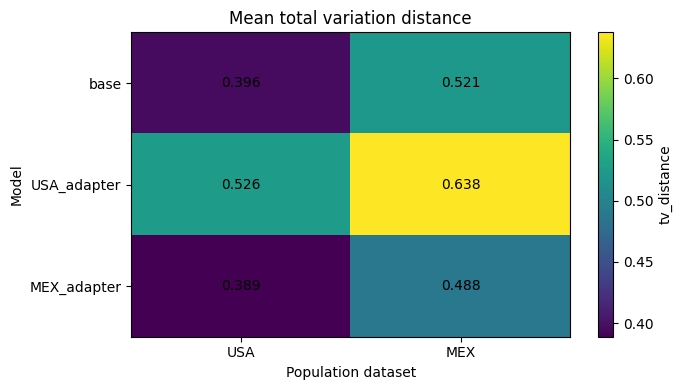

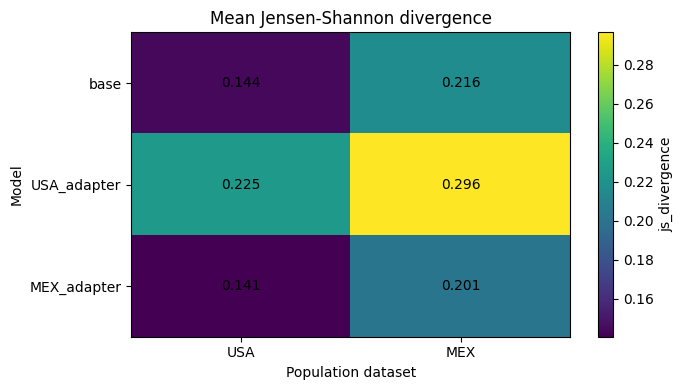

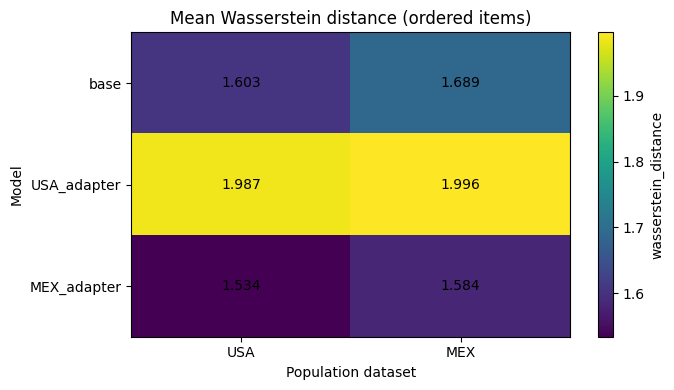

In [ ]:
def plot_metric_heatmap(summary, metric, title=None):
    table = summary.loc[summary["metric"].eq(metric)].pivot(
        index="model", columns="eval_country", values="mean"
    )
    table = table.reindex(index=["base", "USA_adapter", "MEX_adapter"])
    table = table.reindex(columns=DATA_COUNTRY_CODES)

    fig, ax = plt.subplots(figsize=(7, 4))
    image = ax.imshow(table.to_numpy(dtype=float), aspect="auto")
    ax.set_xticks(range(len(table.columns)), labels=table.columns)
    ax.set_yticks(range(len(table.index)), labels=table.index)
    ax.set_xlabel("Population dataset")
    ax.set_ylabel("Model")
    ax.set_title(title or metric)

    for row_index in range(len(table.index)):
        for column_index in range(len(table.columns)):
            value = table.iloc[row_index, column_index]
            ax.text(column_index, row_index, f"{value:.3f}", ha="center", va="center")

    fig.colorbar(image, ax=ax, label=metric)
    plt.tight_layout()
    plt.show()


plot_metric_heatmap(bootstrap_summary, "tv_distance", "Mean total variation distance")
plot_metric_heatmap(bootstrap_summary, "js_divergence", "Mean Jensen-Shannon divergence")
plot_metric_heatmap(bootstrap_summary, "wasserstein_distance", "Mean Wasserstein distance (ordered items)")

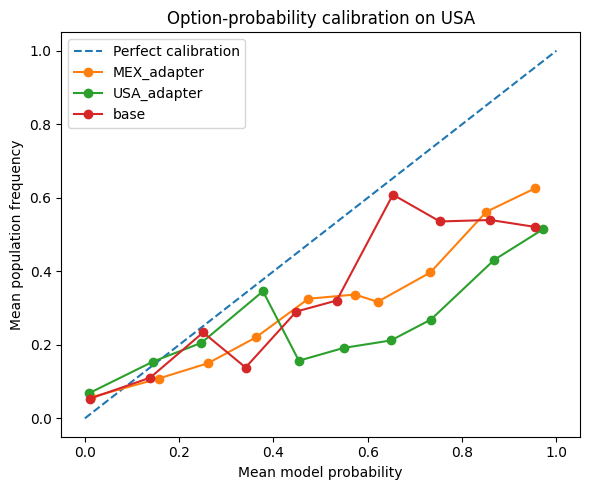

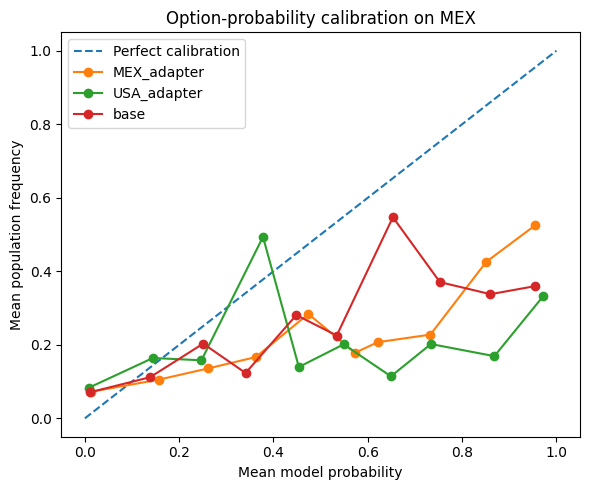

In [ ]:
def plot_calibration(calibration_table):
    for eval_country in DATA_COUNTRY_CODES:
        subset = calibration_table.loc[calibration_table["eval_country"].eq(eval_country)]
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

        for model_name, model_group in subset.groupby("model"):
            ax.plot(
                model_group["mean_predicted_probability"],
                model_group["mean_population_probability"],
                marker="o",
                label=model_name,
            )

        ax.set_xlabel("Mean model probability")
        ax.set_ylabel("Mean population frequency")
        ax.set_title(f"Option-probability calibration on {eval_country}")
        ax.legend()
        plt.tight_layout()
        plt.show()


plot_calibration(calibration_table)

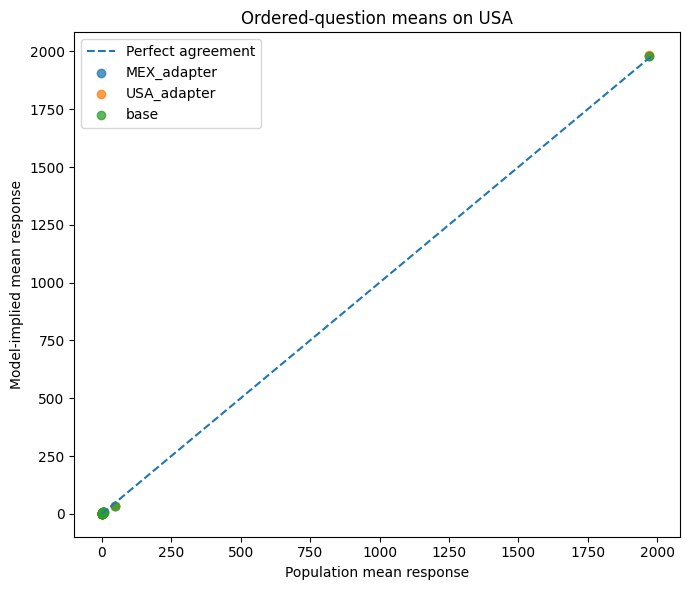

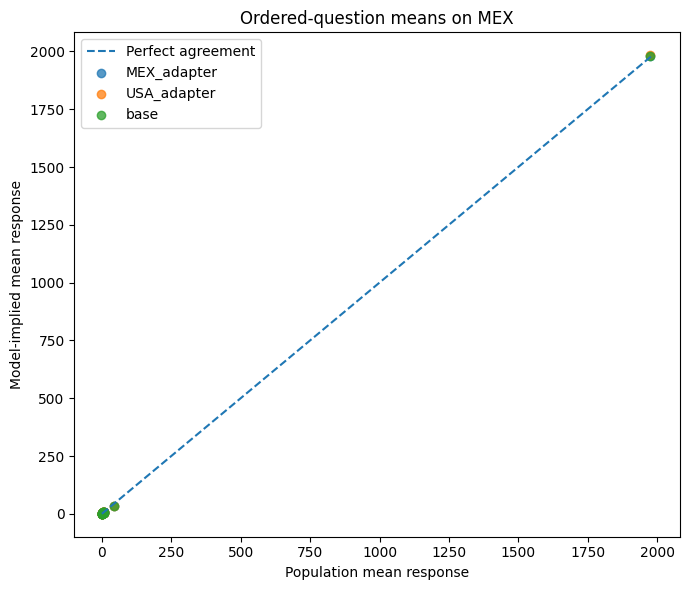

In [ ]:
def plot_ordered_mean_scatter(question_metrics):
    ordered = question_metrics.loc[question_metrics["is_ordered"]].copy()

    for eval_country in DATA_COUNTRY_CODES:
        subset = ordered.loc[ordered["eval_country"].eq(eval_country)]
        fig, ax = plt.subplots(figsize=(7, 6))

        minimum = min(subset["population_mean"].min(), subset["model_mean"].min())
        maximum = max(subset["population_mean"].max(), subset["model_mean"].max())
        ax.plot([minimum, maximum], [minimum, maximum], linestyle="--", label="Perfect agreement")

        for model_name, model_group in subset.groupby("model"):
            ax.scatter(
                model_group["population_mean"],
                model_group["model_mean"],
                alpha=0.75,
                label=model_name,
            )

        ax.set_xlabel("Population mean response")
        ax.set_ylabel("Model-implied mean response")
        ax.set_title(f"Ordered-question means on {eval_country}")
        ax.legend()
        plt.tight_layout()
        plt.show()


plot_ordered_mean_scatter(question_metrics)

## Inspect individual question distributions

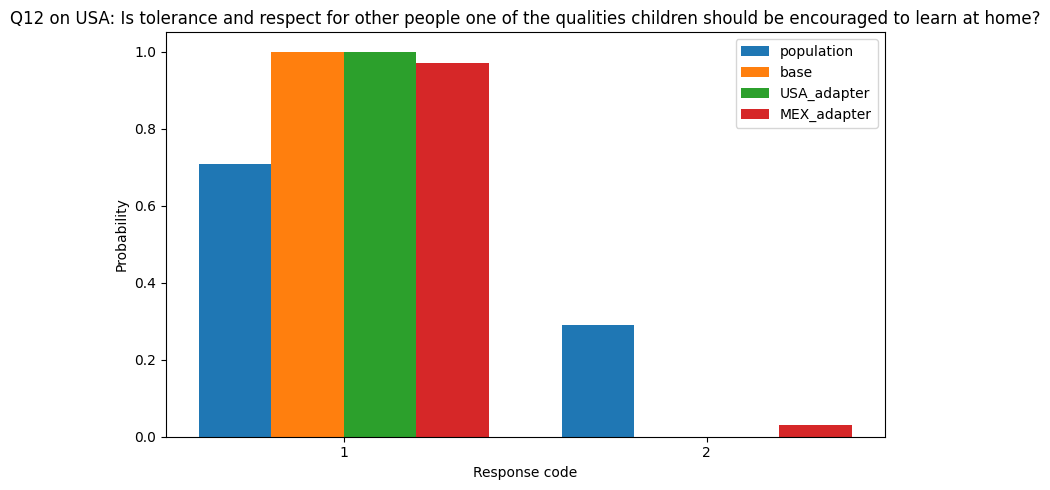

In [ ]:
def plot_question_distribution(question_id, eval_country):
    subset = option_evaluation.loc[
        option_evaluation["question_id"].eq(question_id)
        & option_evaluation["eval_country"].eq(eval_country)
    ].copy()

    if subset.empty:
        raise ValueError(f"No results found for {question_id} / {eval_country}")

    first_model = subset["model"].iloc[0]
    population = subset.loc[subset["model"].eq(first_model)].sort_values("option_index")
    codes = population["option_code"].astype(str).tolist()
    x = np.arange(len(codes))
    model_names = ["base", "USA_adapter", "MEX_adapter"]
    width = 0.8 / (len(model_names) + 1)

    fig, ax = plt.subplots(figsize=(max(8, len(codes) * 0.8), 5))
    ax.bar(x - 0.4 + width / 2, population["population_prob"], width=width, label="population")

    for model_index, model_name in enumerate(model_names, start=1):
        model_rows = subset.loc[subset["model"].eq(model_name)].sort_values("option_index")
        ax.bar(
            x - 0.4 + width / 2 + model_index * width,
            model_rows["model_prob"],
            width=width,
            label=model_name,
        )

    ax.set_xticks(x, labels=codes)
    ax.set_xlabel("Response code")
    ax.set_ylabel("Probability")
    ax.set_title(f"{question_id} on {eval_country}: {population['question_text'].iloc[0]}")
    ax.legend()
    plt.tight_layout()
    plt.show()


# Example; change these values to inspect any question/country.
plot_question_distribution(question_specs[0]["question_id"], DATA_COUNTRY_CODES[0])

## Dimension analysis

In [ ]:
# ============================================================
# Results analysis by GPS dimension
# ============================================================

required_columns = {
    "model",
    "eval_country",
    "relationship",
    "question_id",
    "gps_dimension",
    "tv_distance",
    "js_divergence",
    "brier_score",
    "cross_entropy",
    "wasserstein_distance",
    "abs_mean_error",
    "abs_std_error",
    "mean_error",
    "std_error",
    "top_option_match",
}

missing_columns = required_columns.difference(question_metrics.columns)
if missing_columns:
    raise ValueError(
        "question_metrics is missing required columns: "
        f"{sorted(missing_columns)}"
    )

gps_question_metrics = question_metrics.copy()

# Normalize missing or empty GPS-dimension labels.
gps_question_metrics["gps_dimension"] = (
    gps_question_metrics["gps_dimension"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
    .fillna("Unspecified")
)

GPS_ANALYSIS_METRICS = [
    "tv_distance",
    "js_divergence",
    "brier_score",
    "cross_entropy",
    "wasserstein_distance",
    "abs_mean_error",
    "abs_std_error",
]

In [ ]:
# ------------------------------------------------------------
# 1. Absolute model performance by GPS dimension
# ------------------------------------------------------------

def summarize_metrics_by_gps_dimension(
    metrics_df,
    metric_columns=GPS_ANALYSIS_METRICS,
):
    rows = []

    grouping_columns = [
        "model",
        "eval_country",
        "relationship",
        "gps_dimension",
    ]

    for group_keys, group in metrics_df.groupby(
        grouping_columns,
        dropna=False,
        sort=False,
    ):
        model_name, eval_country, relationship, gps_dimension = group_keys

        for metric in metric_columns:
            values = pd.to_numeric(group[metric], errors="coerce")
            values = values[np.isfinite(values)]

            if values.empty:
                continue

            mean_value, ci_low, ci_high = bootstrap_mean_ci(
                values.to_numpy()
            )

            rows.append({
                "model": model_name,
                "eval_country": eval_country,
                "relationship": relationship,
                "gps_dimension": gps_dimension,
                "metric": metric,
                "mean": mean_value,
                "median": float(values.median()),
                "std_across_questions": (
                    float(values.std(ddof=1))
                    if len(values) > 1
                    else np.nan
                ),
                "ci_2.5%": ci_low,
                "ci_97.5%": ci_high,
                "n_questions": int(len(values)),
            })

    return pd.DataFrame(rows)


gps_dimension_metric_summary = summarize_metrics_by_gps_dimension(
    gps_question_metrics
)

gps_dimension_metric_summary.to_csv(
    RESULTS_DIR / "survey_metrics_by_gps_dimension_with_ci.csv",
    index=False,
)

primary_gps_metrics = gps_dimension_metric_summary[
    gps_dimension_metric_summary["metric"].isin([
        "tv_distance",
        "js_divergence",
        "wasserstein_distance",
        "abs_mean_error",
    ])
].copy()

display(
    primary_gps_metrics.sort_values([
        "gps_dimension",
        "eval_country",
        "metric",
        "mean",
    ])
)


# A wide table that makes model comparisons easier.
gps_performance_wide = (
    primary_gps_metrics
    .assign(
        condition=lambda df: (
            df["model"].astype(str)
            + "_on_"
            + df["eval_country"].astype(str)
        )
    )
    .pivot_table(
        index=["gps_dimension", "metric"],
        columns="condition",
        values="mean",
    )
    .reset_index()
)

gps_performance_wide.to_csv(
    RESULTS_DIR / "survey_metrics_by_gps_dimension_wide.csv",
    index=False,
)

display(gps_performance_wide)

,model,eval_country,relationship,gps_dimension,metric,mean,median,std_across_questions,ci_2.5%,ci_97.5%,n_questions
292,MEX_adapter,MEX,matched,Unspecified,abs_mean_error,4.265949,3.390020,3.453424,1.646190,7.160185,4
96,base,MEX,base,Unspecified,abs_mean_error,4.613955,4.361449,2.894558,2.274105,6.953805,4
194,USA_adapter,MEX,cross,Unspecified,abs_mean_error,5.380922,5.347967,3.739635,2.217288,8.544557,4
288,MEX_adapter,MEX,matched,Unspecified,js_divergence,0.228701,0.268064,0.131637,0.109012,0.311060,5
92,base,MEX,base,Unspecified,js_divergence,0.253150,0.240406,0.167260,0.114303,0.380557,5
...,...,...,...,...,...,...,...,...,...,...,...
210,MEX_adapter,USA,cross,trust,tv_distance,0.315334,0.277406,0.106710,0.262365,0.375234,12
112,USA_adapter,USA,matched,trust,tv_distance,0.398315,0.366892,0.105864,0.342016,0.462047,12
18,base,USA,base,trust,wasserstein_distance,0.330702,0.314416,0.155686,0.248396,0.419787,12
214,MEX_adapter,USA,cross,trust,wasserstein_distance,0.383533,0.350221,0.100661,0.332932,0.440656,12


condition,gps_dimension,metric,MEX_adapter_on_MEX,MEX_adapter_on_USA,USA_adapter_on_MEX,USA_adapter_on_USA,base_on_MEX,base_on_USA
0,Unspecified,abs_mean_error,4.265949,6.259730,5.380922,7.374703,4.613955,6.607736
1,Unspecified,js_divergence,0.228701,0.215212,0.300275,0.275818,0.253150,0.225049
2,Unspecified,tv_distance,0.514753,0.493832,0.596385,0.563152,0.543777,0.501716
3,Unspecified,wasserstein_distance,5.756010,7.182903,6.856668,8.246460,5.875415,7.378782
4,altruism,abs_mean_error,0.206832,0.293186,0.916851,0.830497,0.805373,0.719019
5,altruism,js_divergence,0.034914,0.052659,0.294145,0.263498,0.141541,0.109348
6,altruism,tv_distance,0.151805,0.199346,0.709559,0.662018,0.449957,0.402416
7,altruism,wasserstein_distance,0.206832,0.293186,0.916851,0.830497,0.805373,0.719019
8,negrecip,abs_mean_error,1.250370,0.363219,1.605171,1.787308,1.490832,0.351023
9,negrecip,js_divergence,0.197507,0.146321,0.346899,0.361350,0.197863,0.135060


In [ ]:

# ------------------------------------------------------------
# 2. Adapter improvement over the base model by GPS dimension
#
# Positive improvement means the adapter has LOWER error than
# the base model on the same questions and population.
# ------------------------------------------------------------

def compare_adapters_with_base_by_gps(metrics_df):
    base_columns = [
        "eval_country",
        "question_id",
        "gps_dimension",
    ] + GPS_ANALYSIS_METRICS

    base = metrics_df.loc[
        metrics_df["model"].eq("base"),
        base_columns,
    ].copy()

    base = base.rename(columns={
        metric: f"base_{metric}"
        for metric in GPS_ANALYSIS_METRICS
    })

    adapters = metrics_df.loc[
        metrics_df["model"].ne("base")
    ].copy()

    comparison = adapters.merge(
        base,
        on=[
            "eval_country",
            "question_id",
            "gps_dimension",
        ],
        how="inner",
        validate="many_to_one",
    )

    for metric in GPS_ANALYSIS_METRICS:
        comparison[f"improvement_{metric}"] = (
            comparison[f"base_{metric}"] - comparison[metric]
        )

    return comparison


def summarize_gps_base_improvements(comparison_df):
    rows = []

    grouping_columns = [
        "model",
        "eval_country",
        "relationship",
        "gps_dimension",
    ]

    for group_keys, group in comparison_df.groupby(
        grouping_columns,
        dropna=False,
        sort=False,
    ):
        model_name, eval_country, relationship, gps_dimension = group_keys

        for metric in GPS_ANALYSIS_METRICS:
            improvement_column = f"improvement_{metric}"

            values = pd.to_numeric(
                group[improvement_column],
                errors="coerce",
            )
            values = values[np.isfinite(values)]

            if values.empty:
                continue

            mean_value, ci_low, ci_high = bootstrap_mean_ci(
                values.to_numpy()
            )

            rows.append({
                "model": model_name,
                "eval_country": eval_country,
                "relationship": relationship,
                "gps_dimension": gps_dimension,
                "metric": metric,
                "mean_improvement_over_base": mean_value,
                "median_improvement_over_base": float(values.median()),
                "ci_2.5%": ci_low,
                "ci_97.5%": ci_high,
                "fraction_questions_improved": float(
                    (values > 0).mean()
                ),
                "n_questions": int(len(values)),
            })

    return pd.DataFrame(rows)


gps_base_comparison_by_question = (
    compare_adapters_with_base_by_gps(gps_question_metrics)
)

gps_base_improvement_summary = summarize_gps_base_improvements(
    gps_base_comparison_by_question
)

gps_base_comparison_by_question.to_csv(
    RESULTS_DIR
    / "survey_adapter_improvement_vs_base_by_question_and_gps_dimension.csv",
    index=False,
)

gps_base_improvement_summary.to_csv(
    RESULTS_DIR
    / "survey_adapter_improvement_vs_base_by_gps_dimension.csv",
    index=False,
)

display(
    gps_base_improvement_summary[
        gps_base_improvement_summary["metric"].isin([
            "tv_distance",
            "js_divergence",
            "wasserstein_distance",
            "abs_mean_error",
        ])
    ].sort_values([
        "gps_dimension",
        "eval_country",
        "metric",
        "mean_improvement_over_base",
    ], ascending=[True, True, True, False])
)



,model,eval_country,relationship,gps_dimension,metric,mean_improvement_over_base,median_improvement_over_base,ci_2.5%,ci_97.5%,fraction_questions_improved,n_questions
194,MEX_adapter,MEX,matched,Unspecified,abs_mean_error,0.348006,0.627915,-0.386808,0.971430,0.750000,4
96,USA_adapter,MEX,cross,Unspecified,abs_mean_error,-0.766967,-0.595811,-1.590752,0.056817,0.500000,4
190,MEX_adapter,MEX,matched,Unspecified,js_divergence,0.024449,-0.011368,-0.021930,0.104717,0.400000,5
92,USA_adapter,MEX,cross,Unspecified,js_divergence,-0.047125,-0.054864,-0.074184,-0.018799,0.000000,5
189,MEX_adapter,MEX,matched,Unspecified,tv_distance,0.029024,-0.016745,-0.030490,0.120689,0.400000,5
...,...,...,...,...,...,...,...,...,...,...,...
15,USA_adapter,USA,matched,trust,js_divergence,-0.060829,-0.059609,-0.081944,-0.042086,0.000000,12
112,MEX_adapter,USA,cross,trust,tv_distance,-0.053766,-0.018847,-0.138313,0.026036,0.416667,12
14,USA_adapter,USA,matched,trust,tv_distance,-0.136747,-0.131820,-0.195750,-0.085828,0.000000,12
116,MEX_adapter,USA,cross,trust,wasserstein_distance,-0.052831,-0.032715,-0.143742,0.036584,0.416667,12


In [ ]:
gps_base_improvement_summary.groupby(['model', 'eval_country'])[['mean_improvement_over_base',
                                                                 'median_improvement_over_base' ]].mean()

mean_improvement_over_base  median_improvement_over_base
model       eval_country                                                          
MEX_adapter MEX                             0.146532                      0.131987
            USA                             0.095912                      0.067948
USA_adapter MEX                            -0.391498                     -0.350688
            USA                            -0.413189                     -0.364580

In [ ]:
gps_base_improvement_summary.groupby('relationship')[['mean_improvement_over_base','median_improvement_over_base' ]].mean()

,mean_improvement_over_base,median_improvement_over_base
relationship,,
cross,-0.147793,-0.141370
matched,-0.133328,-0.116296


In [ ]:

# ------------------------------------------------------------
# 3. Matched adapter versus cross-country adapter
#
# Positive specificity means the matched-country adapter has
# LOWER error than the other-country adapter.
# ------------------------------------------------------------

def matched_vs_cross_by_gps(metrics_df):
    adapter_metrics = metrics_df.loc[
        metrics_df["model"].ne("base")
    ].copy()

    matched = adapter_metrics.loc[
        adapter_metrics["relationship"].eq("matched")
    ].copy()

    cross = adapter_metrics.loc[
        adapter_metrics["relationship"].eq("cross")
    ].copy()

    matched_columns = [
        "eval_country",
        "question_id",
        "gps_dimension",
        "model",
    ] + GPS_ANALYSIS_METRICS

    cross_columns = [
        "eval_country",
        "question_id",
        "gps_dimension",
        "model",
    ] + GPS_ANALYSIS_METRICS

    matched = matched[matched_columns].rename(columns={
        "model": "matched_model",
        **{
            metric: f"matched_{metric}"
            for metric in GPS_ANALYSIS_METRICS
        },
    })

    cross = cross[cross_columns].rename(columns={
        "model": "cross_model",
        **{
            metric: f"cross_{metric}"
            for metric in GPS_ANALYSIS_METRICS
        },
    })

    comparison = matched.merge(
        cross,
        on=[
            "eval_country",
            "question_id",
            "gps_dimension",
        ],
        how="inner",
        validate="one_to_one",
    )

    for metric in GPS_ANALYSIS_METRICS:
        comparison[f"specificity_{metric}"] = (
            comparison[f"cross_{metric}"]
            - comparison[f"matched_{metric}"]
        )

    return comparison


def summarize_gps_specificity(comparison_df):
    rows = []

    for (eval_country, gps_dimension), group in comparison_df.groupby(
        ["eval_country", "gps_dimension"],
        dropna=False,
        sort=False,
    ):
        for metric in GPS_ANALYSIS_METRICS:
            specificity_column = f"specificity_{metric}"

            values = pd.to_numeric(
                group[specificity_column],
                errors="coerce",
            )
            values = values[np.isfinite(values)]

            if values.empty:
                continue

            mean_value, ci_low, ci_high = bootstrap_mean_ci(
                values.to_numpy()
            )

            rows.append({
                "eval_country": eval_country,
                "gps_dimension": gps_dimension,
                "metric": metric,
                "mean_cross_minus_matched": mean_value,
                "median_cross_minus_matched": float(values.median()),
                "ci_2.5%": ci_low,
                "ci_97.5%": ci_high,
                "fraction_questions_matched_better": float(
                    (values > 0).mean()
                ),
                "n_questions": int(len(values)),
            })

    return pd.DataFrame(rows)


gps_specificity_by_question = matched_vs_cross_by_gps(
    gps_question_metrics
)

gps_specificity_summary = summarize_gps_specificity(
    gps_specificity_by_question
)

gps_specificity_by_question.to_csv(
    RESULTS_DIR
    / "survey_matched_vs_cross_specificity_by_question_and_gps_dimension.csv",
    index=False,
)

gps_specificity_summary.to_csv(
    RESULTS_DIR
    / "survey_matched_vs_cross_specificity_by_gps_dimension.csv",
    index=False,
)

display(
    gps_specificity_summary[
        gps_specificity_summary["metric"].isin([
            "tv_distance",
            "js_divergence",
            "wasserstein_distance",
            "abs_mean_error",
        ])
    ].sort_values([
        "gps_dimension",
        "eval_country",
        "metric",
    ])
)


,eval_country,gps_dimension,metric,mean_cross_minus_matched,median_cross_minus_matched,ci_2.5%,ci_97.5%,fraction_questions_matched_better,n_questions
96,MEX,Unspecified,abs_mean_error,1.114973,0.660669,0.271999,2.307488,1.000000,4
92,MEX,Unspecified,js_divergence,0.071574,0.055130,0.022759,0.142003,1.000000,5
91,MEX,Unspecified,tv_distance,0.081631,0.056028,0.027870,0.158062,1.000000,5
95,MEX,Unspecified,wasserstein_distance,1.100658,0.909620,0.339316,2.053039,1.000000,4
47,USA,Unspecified,abs_mean_error,-1.114973,-0.660669,-2.307488,-0.271999,0.000000,4
43,USA,Unspecified,js_divergence,-0.060605,-0.049988,-0.106413,-0.023002,0.000000,5
42,USA,Unspecified,tv_distance,-0.069320,-0.045279,-0.125576,-0.027673,0.000000,5
46,USA,Unspecified,wasserstein_distance,-1.063558,-0.741998,-2.118073,-0.330602,0.000000,4
75,MEX,altruism,abs_mean_error,0.710018,0.752777,0.535986,0.841291,1.000000,3
71,MEX,altruism,js_divergence,0.259231,0.296623,0.140654,0.340415,1.000000,3


In [ ]:
# ------------------------------------------------------------
# 4. Mean, dispersion, entropy and top-option diagnostics
# ------------------------------------------------------------

gps_moment_summary = (
    gps_question_metrics
    .groupby([
        "model",
        "eval_country",
        "relationship",
        "gps_dimension",
    ], dropna=False, as_index=False)
    .agg(
        mean_response_bias=("mean_error", "mean"),
        median_response_bias=("mean_error", "median"),
        mean_absolute_response_error=("abs_mean_error", "mean"),
        mean_dispersion_bias=("std_error", "mean"),
        median_dispersion_bias=("std_error", "median"),
        mean_absolute_dispersion_error=("abs_std_error", "mean"),
        mean_entropy_bias=("entropy_error", "mean"),
        top_option_match_rate=("top_option_match", "mean"),
        n_questions=("question_id", "nunique"),
        n_ordered_questions=("mean_error", "count"),
    )
)

gps_moment_summary.to_csv(
    RESULTS_DIR / "survey_moment_diagnostics_by_gps_dimension.csv",
    index=False,
)

display(
    gps_moment_summary.sort_values([
        "gps_dimension",
        "eval_country",
        "model",
    ])
)


,model,eval_country,relationship,gps_dimension,mean_response_bias,median_response_bias,mean_absolute_response_error,mean_dispersion_bias,median_dispersion_bias,mean_absolute_dispersion_error,mean_entropy_bias,top_option_match_rate,n_questions,n_ordered_questions
0,MEX_adapter,MEX,matched,Unspecified,-0.188065,1.646190,4.265949,-5.225173,-4.356075,5.237484,-1.002484,0.000000,5,4
14,USA_adapter,MEX,cross,Unspecified,0.746123,2.217288,5.380922,-6.613573,-5.839840,6.613573,-1.318511,0.000000,5,4
28,base,MEX,base,Unspecified,0.579178,2.274105,4.613955,-5.369994,-4.183093,5.369994,-1.049297,0.200000,5,4
7,MEX_adapter,USA,cross,Unspecified,-0.640605,0.534168,6.259730,-5.509472,-4.556424,5.585815,-0.993118,0.000000,5,4
21,USA_adapter,USA,matched,Unspecified,0.293583,1.105266,7.374703,-6.897871,-6.047323,6.897871,-1.309144,0.000000,5,4
35,base,USA,base,Unspecified,0.126638,1.162083,6.607736,-5.654293,-4.421267,5.654293,-1.039930,0.200000,5,4
1,MEX_adapter,MEX,matched,altruism,-0.206832,-0.209796,0.206832,-0.337606,-0.333074,0.337606,-0.443414,1.000000,3,3
15,USA_adapter,MEX,cross,altruism,0.916851,0.962573,0.916851,0.031156,0.006482,0.047119,0.276127,0.000000,3,3
29,base,MEX,base,altruism,0.805373,0.965072,0.805373,0.286036,0.284281,0.286036,0.412727,0.333333,3,3
8,MEX_adapter,USA,cross,altruism,-0.293186,-0.214862,0.293186,-0.409759,-0.340507,0.409759,-0.526478,1.000000,3,3


In [ ]:
# ------------------------------------------------------------
# 5. Question counts per GPS dimension
# ------------------------------------------------------------

gps_question_counts = (
    gps_question_metrics[
        ["question_id", "gps_dimension", "response_type", "is_ordered"]
    ]
    .drop_duplicates()
    .groupby("gps_dimension", as_index=False)
    .agg(
        n_questions=("question_id", "nunique"),
        n_response_types=("response_type", "nunique"),
        n_ordered_questions=("is_ordered", "sum"),
    )
    .sort_values("gps_dimension")
)

gps_question_counts.to_csv(
    RESULTS_DIR / "survey_question_counts_by_gps_dimension.csv",
    index=False,
)

display(gps_question_counts)



,gps_dimension,n_questions,n_response_types,n_ordered_questions
0,Unspecified,5,4,4
1,altruism,3,1,3
2,negrecip,4,1,4
3,patience,4,3,4
4,posrecip,3,3,2
5,risktaking,4,1,4
6,trust,12,2,12


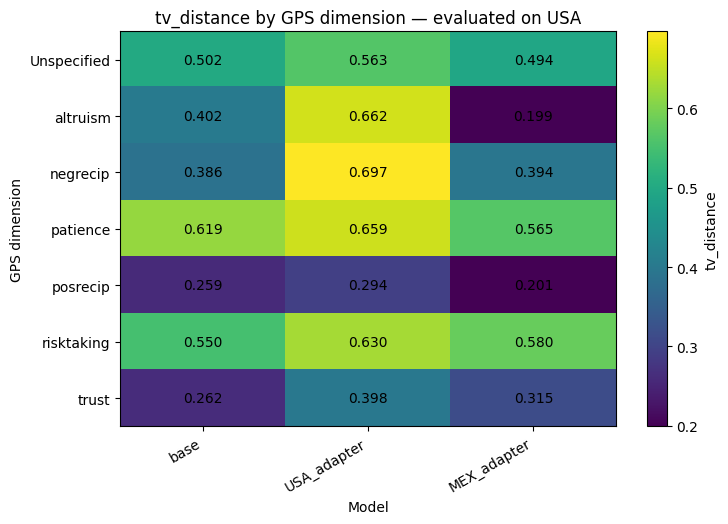

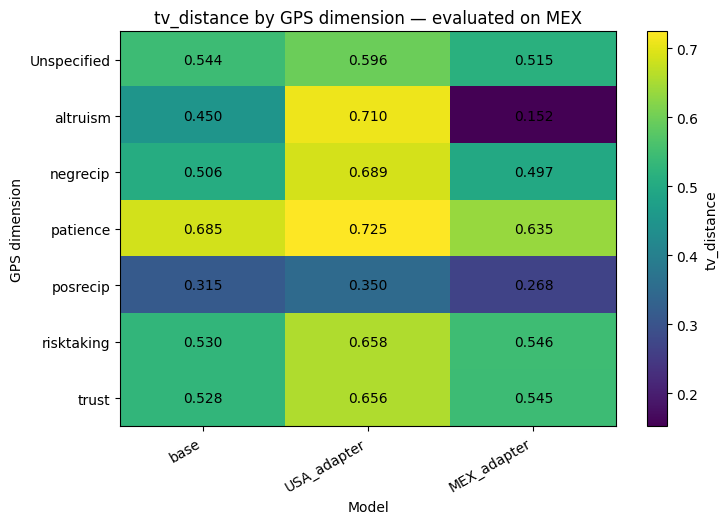

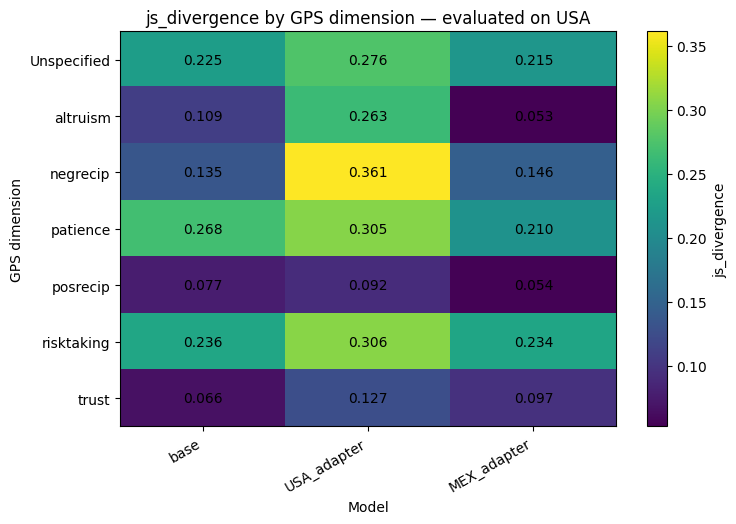

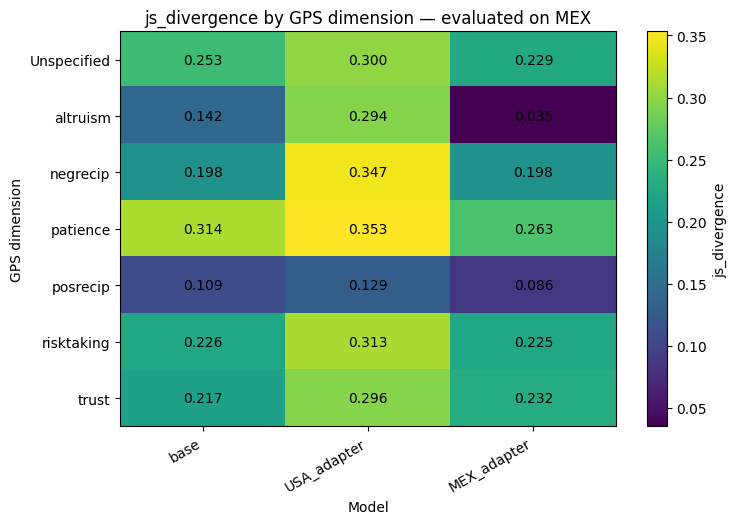

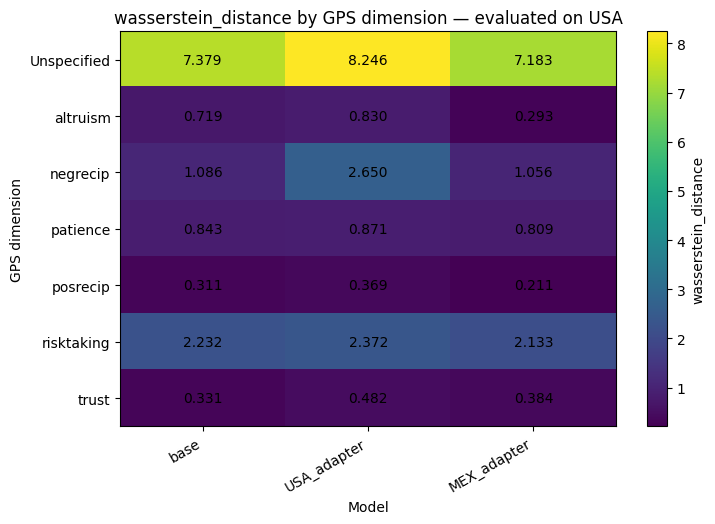

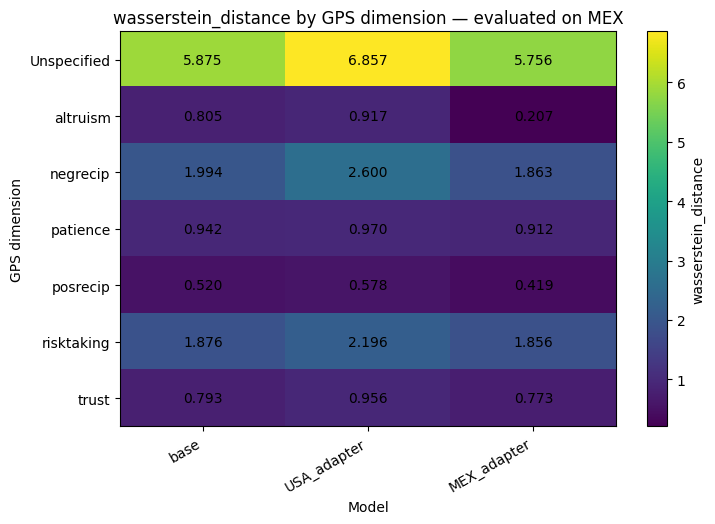

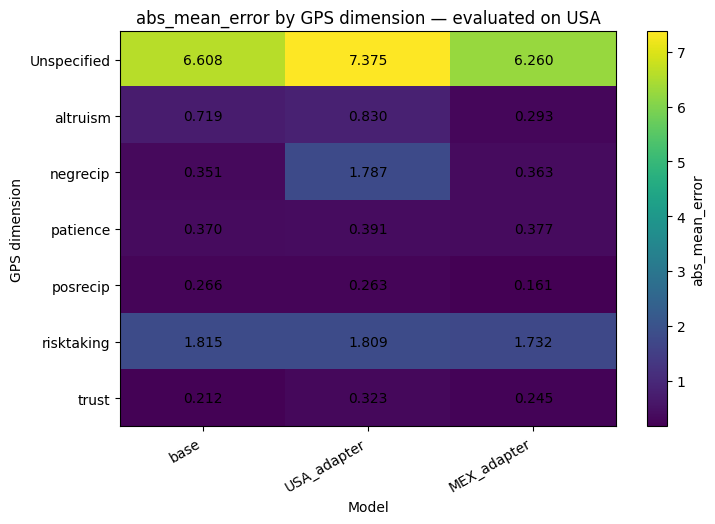

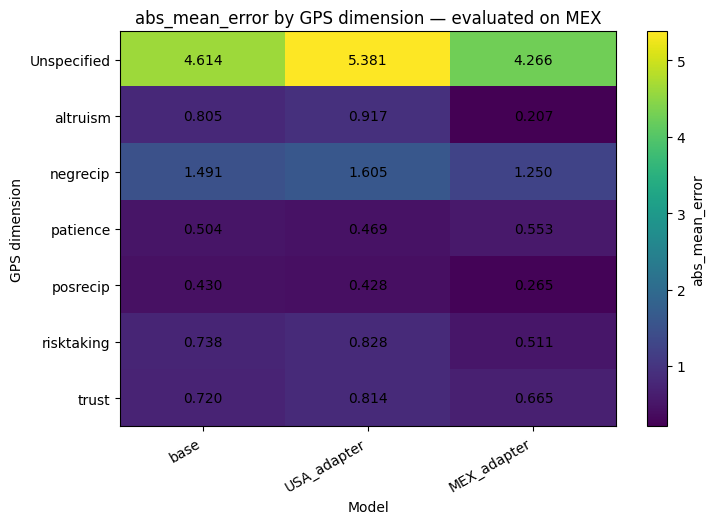

In [ ]:

# ------------------------------------------------------------
# 6. Heatmaps by GPS dimension
# ------------------------------------------------------------

def plot_gps_dimension_metric_heatmaps(
    summary_df,
    metric,
    value_column="mean",
):
    metric_data = summary_df.loc[
        summary_df["metric"].eq(metric)
    ].copy()

    if metric_data.empty:
        print(f"No finite results available for {metric}.")
        return

    preferred_model_order = [
        "base",
        "USA_adapter",
        "MEX_adapter",
    ]

    for eval_country in DATA_COUNTRY_CODES:
        subset = metric_data.loc[
            metric_data["eval_country"].eq(eval_country)
        ]

        if subset.empty:
            continue

        table = subset.pivot_table(
            index="gps_dimension",
            columns="model",
            values=value_column,
            aggfunc="mean",
        )

        available_models = [
            model
            for model in preferred_model_order
            if model in table.columns
        ]
        remaining_models = [
            model
            for model in table.columns
            if model not in available_models
        ]

        table = table.reindex(
            columns=available_models + remaining_models
        ).sort_index()

        fig_height = max(4.0, 0.55 * len(table.index) + 1.5)
        fig_width = max(7.0, 1.7 * len(table.columns) + 2.5)

        fig, ax = plt.subplots(
            figsize=(fig_width, fig_height)
        )

        image = ax.imshow(
            table.to_numpy(dtype=float),
            aspect="auto",
        )

        ax.set_xticks(
            range(len(table.columns)),
            labels=table.columns,
            rotation=30,
            ha="right",
        )
        ax.set_yticks(
            range(len(table.index)),
            labels=table.index,
        )

        ax.set_xlabel("Model")
        ax.set_ylabel("GPS dimension")
        ax.set_title(
            f"{metric} by GPS dimension — evaluated on {eval_country}"
        )

        for row_index in range(len(table.index)):
            for column_index in range(len(table.columns)):
                value = table.iloc[row_index, column_index]
                label = "NA" if pd.isna(value) else f"{value:.3f}"

                ax.text(
                    column_index,
                    row_index,
                    label,
                    ha="center",
                    va="center",
                )

        fig.colorbar(image, ax=ax, label=metric)
        plt.tight_layout()
        plt.show()


for metric_name in [
    "tv_distance",
    "js_divergence",
    "wasserstein_distance",
    "abs_mean_error",
]:
    plot_gps_dimension_metric_heatmaps(
        gps_dimension_metric_summary,
        metric=metric_name,
    )



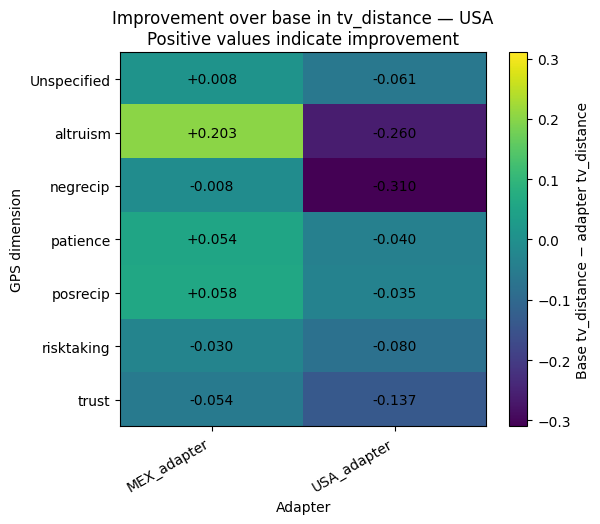

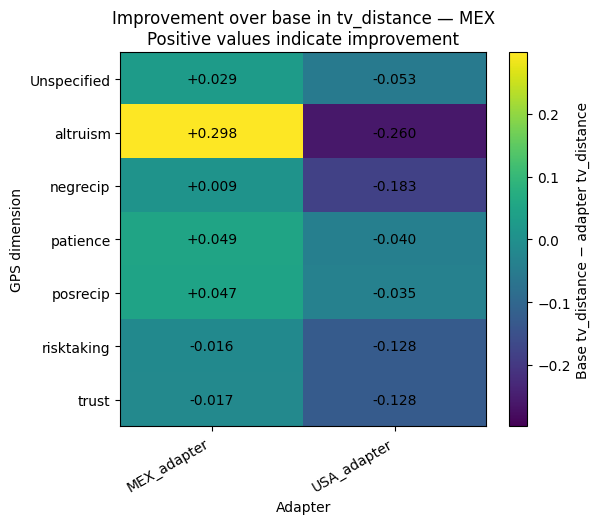

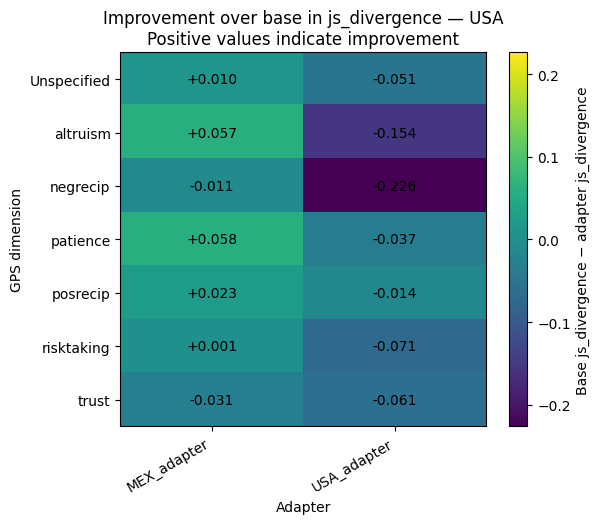

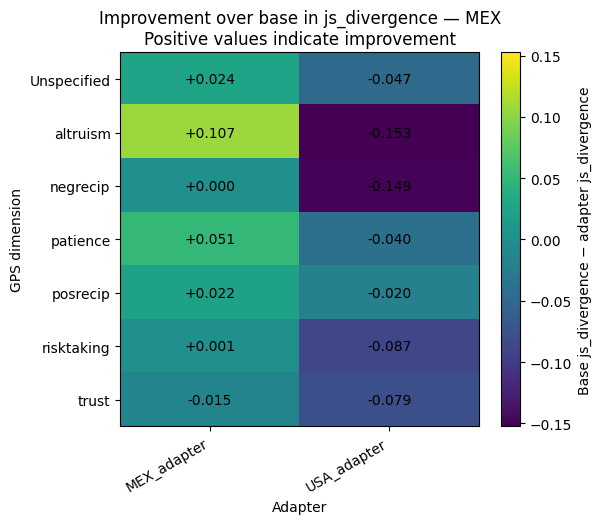

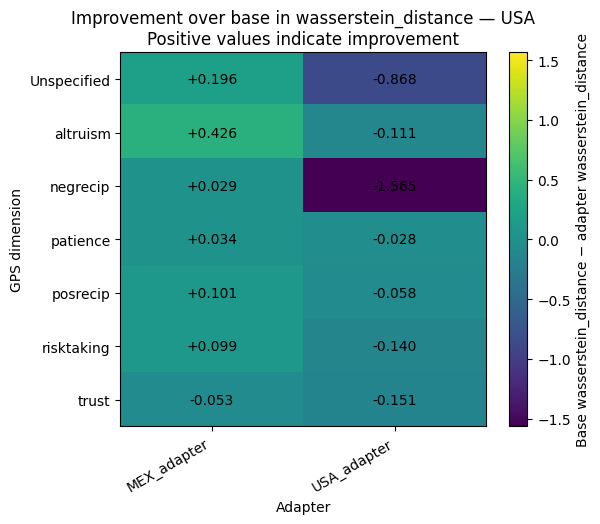

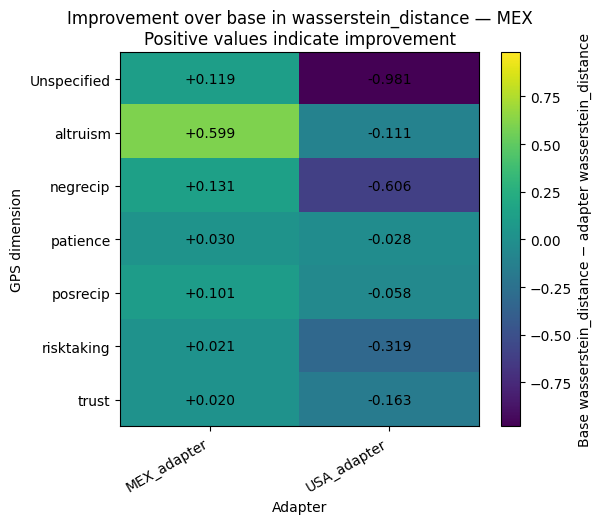

GPS-dimension analysis complete.
Results saved to: /content/drive/MyDrive/DPO/eval_new_data/eval_results_wvs_wave7


In [ ]:

# ------------------------------------------------------------
# 7. Improvement-over-base heatmaps
# ------------------------------------------------------------

def plot_gps_improvement_heatmaps(
    improvement_summary,
    metric,
):
    subset = improvement_summary.loc[
        improvement_summary["metric"].eq(metric)
    ].copy()

    if subset.empty:
        print(f"No adapter improvement results for {metric}.")
        return

    for eval_country in DATA_COUNTRY_CODES:
        country_data = subset.loc[
            subset["eval_country"].eq(eval_country)
        ]

        if country_data.empty:
            continue

        table = country_data.pivot_table(
            index="gps_dimension",
            columns="model",
            values="mean_improvement_over_base",
            aggfunc="mean",
        ).sort_index()

        fig_height = max(4.0, 0.55 * len(table.index) + 1.5)
        fig_width = max(6.0, 1.8 * len(table.columns) + 2.5)

        fig, ax = plt.subplots(
            figsize=(fig_width, fig_height)
        )

        max_absolute_value = np.nanmax(
            np.abs(table.to_numpy(dtype=float))
        )

        if not np.isfinite(max_absolute_value) or max_absolute_value == 0:
            max_absolute_value = 1.0

        image = ax.imshow(
            table.to_numpy(dtype=float),
            aspect="auto",
            vmin=-max_absolute_value,
            vmax=max_absolute_value,
        )

        ax.set_xticks(
            range(len(table.columns)),
            labels=table.columns,
            rotation=30,
            ha="right",
        )
        ax.set_yticks(
            range(len(table.index)),
            labels=table.index,
        )

        ax.set_xlabel("Adapter")
        ax.set_ylabel("GPS dimension")
        ax.set_title(
            f"Improvement over base in {metric} — {eval_country}\n"
            "Positive values indicate improvement"
        )

        for row_index in range(len(table.index)):
            for column_index in range(len(table.columns)):
                value = table.iloc[row_index, column_index]
                label = "NA" if pd.isna(value) else f"{value:+.3f}"

                ax.text(
                    column_index,
                    row_index,
                    label,
                    ha="center",
                    va="center",
                )

        fig.colorbar(
            image,
            ax=ax,
            label=f"Base {metric} − adapter {metric}",
        )
        plt.tight_layout()
        plt.show()


for metric_name in [
    "tv_distance",
    "js_divergence",
    "wasserstein_distance",
]:
    plot_gps_improvement_heatmaps(
        gps_base_improvement_summary,
        metric=metric_name,
    )


print("GPS-dimension analysis complete.")
print(f"Results saved to: {RESULTS_DIR}")

## Interpretation guide

Lower values are better for all error/divergence metrics. The most important comparisons are:

1. **Adapter versus base on the same population:** positive `mean_improvement_over_base` means the adapter improved on the base model.
2. **Matched versus cross adapter:** positive `mean_cross_minus_matched` means the population's own adapter fits better than the other-country adapter.
3. **Distribution shape:** use TV/JS/Brier and calibration, not only the mean response.
4. **Ordered scales:** use Wasserstein distance plus mean and standard-deviation errors. These retain information about both central tendency and dispersion.
5. **Numeric-open questions:** exact-distribution divergence can be strict, so emphasize Wasserstein and moment errors for Q261/Q262.

The weighted population distributions, option-level model probabilities, per-question metrics, bootstrap summaries, base-model improvements, and matched-versus-cross comparisons are all written to `RESULTS_DIR`.